In [1]:
import pickle, gzip
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt
import re
import os
import json

In [6]:
def save_figure(fig, figname, outdir=''):
    outname=os.path.join(outdir, f"{figname}.png")
    fig.savefig(outname, bbox_inches='tight', format='png')
    print(f'plot saved to {outname}')
    plt.close(fig)

def get_shape_syst_lst(base_histo, ignore_list=[]):
    # Get unique systematic base names (e.g., "ISR" from "ISRUp")
    all_syst_var_lst = list(base_histo.axes["systematic"])
    syst_var_lst = []
    for name in all_syst_var_lst:
        if name.endswith("Up"):
            base_name = name[:-2] # strip "Up" to get the base systematic name
            if base_name in ignore_list: continue
            if base_name not in syst_var_lst:
                syst_var_lst.append(base_name)
                
    return syst_var_lst

year_naming = {
    "2016APV": "UL16APV",
    "2016": "UL16",
    "2017": "UL17",
    "2018": "UL18",
}

# def get_syst_year_tag(syst_name, year_naming):

#     sorted_years = sorted(
#         year_naming.keys(),
#         key=len,
#         reverse=True
#     )
#     for year in sorted_years:
#         if year in syst_name:
#             return year_naming[year]
#     return None

# def is_year_specifc(syst_name):
#     if ('16' in syst_name) or ('17' in syst_name) or ('18' in syst_name)
#         return True 
#     else: return False

def get_syst_year(syst_name):
    for syst_year in year_naming:
        if syst_year in syst_name:
            return syst_year
    return None


def get_proc_year(proc_name):
    for syst_year, proc_year in year_naming.items():
        if proc_name.endswith(proc_year):
            return syst_year
    return None


def get_shape_syst_arrs(base_histo, syst_var_lst, PDF_var_histo=None):
    # Mapping between systematic name years and process axis year tags
    year_naming = {
        "2016APV": "UL16APV",
        "2016": "UL16",
        "2017": "UL17",
        "2018": "UL18",
    }

    p_arr_rel_lst = []
    m_arr_rel_lst = []

    for syst_name in syst_var_lst:
        if syst_name in ["renormfact", "LHEPDFweight"]:
            continue

        # --- PDF Uncertainty Handling ---
        if syst_name == "PDF" and PDF_var_histo:
            print("running PDF uncertainties")
            relevant_samples_lst = list(PDF_var_histo.axes["process"])
            h = PDF_var_histo[{"process": relevant_samples_lst}]

            nominal = h[{'PDFindex': 0}].values()
            variations = h[{"PDFindex": slice(1, None)}].values()

            diff_sq = np.square(variations - nominal[..., np.newaxis])
            sigma_pdf = np.sqrt(np.sum(diff_sq, axis=-1))

            total_sigma_pdf = np.sum(sigma_pdf, axis=0)

            # PDF uncertainties are symmetric; append directly to quadrature lists
            p_arr_rel_lst.append(total_sigma_pdf**2)
            m_arr_rel_lst.append(total_sigma_pdf**2)
            continue
            
        elif syst_name == "PDF": 
            print("NOT running PDF uncertainties")
            continue

        # --- Standard & Year-Specific Systematic Handling ---
        
        # Determine if this systematic is tied to a specific year
        syst_year_suffix = None
        target_process_year = None
        for yr_syst, yr_proc in year_naming.items():
            if yr_syst in syst_name:
                syst_year_suffix = yr_syst
                target_process_year = yr_proc
                break

        # Identify all relevant samples that have this systematic variation
        h_up = base_histo[{"systematic": syst_name + "Up"}]
        all_relevant_samples = list(h_up.axes["process"])

        if syst_year_suffix:
            # Target exactly what should vary
            if target_process_year == "UL16":
                # For 2016, look for UL16 but explicitly ignore UL16APV
                var_samples = [s for s in all_relevant_samples if "UL16" in s and "UL16APV" not in s]
            else:
                # For 2016APV, 2017, 2018, standard substring match works flawlessly
                var_samples = [s for s in all_relevant_samples if target_process_year in s]
            
            # Anything that isn't varying MUST be kept as nominal.
            nom_samples = [s for s in all_relevant_samples if s not in var_samples]

            # Total Nominal (all relevant samples across all years)
            n_arr = base_histo[{"process": all_relevant_samples, "systematic": "nominal"}]
            n_arr = n_arr[{"process": sum}].values()

            # Calculate Up Variation: (Target Year Up) + (Other Years Nominal)
            u_arr_var_year = base_histo[{"process": var_samples, "systematic": syst_name + "Up"}][{"process": sum}].values()
            u_arr_nom_years = base_histo[{"process": nom_samples, "systematic": "nominal"}][{"process": sum}].values() if nom_samples else 0
            u_arr_sum = u_arr_var_year + u_arr_nom_years

            # Calculate Down Variation: (Target Year Down) + (Other Years Nominal)
            d_arr_var_year = base_histo[{"process": var_samples, "systematic": syst_name + "Down"}][{"process": sum}].values()
            d_arr_nom_years = base_histo[{"process": nom_samples, "systematic": "nominal"}][{"process": sum}].values() if nom_samples else 0
            d_arr_sum = d_arr_var_year + d_arr_nom_years

        else:
            # Standard treatment for year-correlated
            n_arr = base_histo[{"process": all_relevant_samples, "systematic": "nominal"}][{"process": sum}].values()
            u_arr_sum = base_histo[{"process": all_relevant_samples, "systematic": syst_name + "Up"}][{"process": sum}].values()
            d_arr_sum = base_histo[{"process": all_relevant_samples, "systematic": syst_name + "Down"}][{"process": sum}].values()

        # Differences relative to nominal
        u_arr_rel = u_arr_sum - n_arr
        d_arr_rel = d_arr_sum - n_arr
        
        # Envelope: Extract strictly positive and negative shifts relative to 0
        p_arr_rel = np.maximum.reduce([u_arr_rel, d_arr_rel, np.zeros_like(n_arr)])
        m_arr_rel = np.minimum.reduce([u_arr_rel, d_arr_rel, np.zeros_like(n_arr)])
        
        # Add in quadrature
        p_arr_rel_lst.append(p_arr_rel**2)
        m_arr_rel_lst.append(m_arr_rel**2)

    return [np.sum(m_arr_rel_lst, axis=0), np.sum(p_arr_rel_lst, axis=0)]

def get_shape_syst_arrs_noyears(base_histo, syst_var_lst, PDF_var_histo=None):
    # Get unique systematic base names (e.g., "ISR" from "ISRUp")
    p_arr_rel_lst = []
    m_arr_rel_lst = []

    for syst_name in syst_var_lst:
        # print(f"getting shape syst arr for {syst_name}")
        if syst_name == "renormfact": 
            continue
        if syst_name == "LHEPDFweight":
            continue

        if syst_name == "PDF" and PDF_var_histo:
            print(f"running PDF uncertainties")
            relevant_samples_lst = list(PDF_var_histo.axes["process"])
            h = PDF_var_histo[{"process":relevant_samples_lst}]

            nominal = h[{'PDFindex':0}].values()
            variations = h[{"PDFindex": slice(1, None)}].values()

            diff_sq = np.square(variations - nominal[..., np.newaxis])
            sigma_pdf = np.sqrt(np.sum(diff_sq, axis=-1))

            n_arr = np.sum(nominal, axis=0)
            total_sigma_pdf = np.sum(sigma_pdf, axis=0)

            p_arr_rel_lst.append(total_sigma_pdf**2)
            m_arr_rel_lst.append(total_sigma_pdf**2)
            continue
            
        elif syst_name == "PDF": 
            print(f"NOT running PDF uncertainties")
            continue

        if ('2016' in syst_name) or ('2017' in syst_name) or ('2018' in syst_name): 
            continue

        # Identify relevant samples for this systematic
        h_up = base_histo[{"systematic": syst_name + "Up"}]         # select the "Up" variation syst axis
        relevant_samples_lst = list(h_up.axes["process"])           # get the list of processes that have this syst var

        # Calculate Nominal (n_arr)
        n_arr = base_histo[{"process": relevant_samples_lst, "systematic": "nominal"}]      # select the 'nominal' systematic axis
        n_arr = n_arr[{"process": sum}].values()                                            # sum over the relevant processes

        # Calculate Up/Down variations
        u_arr_sum = base_histo[{"process": relevant_samples_lst, "systematic": syst_name + "Up"}]   # select the samples with an Up variation and the right axis
        u_arr_sum = u_arr_sum[{"process": sum}].values()                                            # sum over all relevant samples 
        
        d_arr_sum = base_histo[{"process": relevant_samples_lst, "systematic": syst_name + "Down"}]
        d_arr_sum = d_arr_sum[{"process": sum}].values()

        # Diff with respect to nominal
        u_arr_rel = u_arr_sum - n_arr
        d_arr_rel = d_arr_sum - n_arr
        
        # Just the ones that increase the yield
        p_arr_rel = np.where(u_arr_rel > 0, u_arr_rel, d_arr_rel)
        m_arr_rel = np.where(u_arr_rel < 0, u_arr_rel, d_arr_rel)

        # Add in quadrature
        p_arr_rel_lst.append(p_arr_rel**2)
        m_arr_rel_lst.append(m_arr_rel**2)

    return [np.sum(m_arr_rel_lst, axis=0), np.sum(p_arr_rel_lst, axis=0)]

In [7]:
hists_EFT = pickle.load(gzip.open("SR_ALL_2j3j_260518.pkl.gz"))
hists_powheg = pickle.load(gzip.open("SR_ALL_Powheg.pkl.gz"))

In [8]:
channel_conversion = {
    "ee_2b_2j":['ee_2b_2j'],
    "ee_2b_3j":['ee_2b_3j', 'ee_2b_4j'],
    "em_2b_2j":['em_2b_2j'],
    "em_2b_3j":['em_2b_3j', 'em_2b_4j'],
    "mm_2b_2j":['mm_2b_2j'],
    "mm_2b_3j":['mm_2b_3j', 'mm_2b_4j'],
}

In [9]:
def add_fake_flow(arr):
    arr = list(arr)
    return [arr[0]] + arr + [arr[-1]]

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


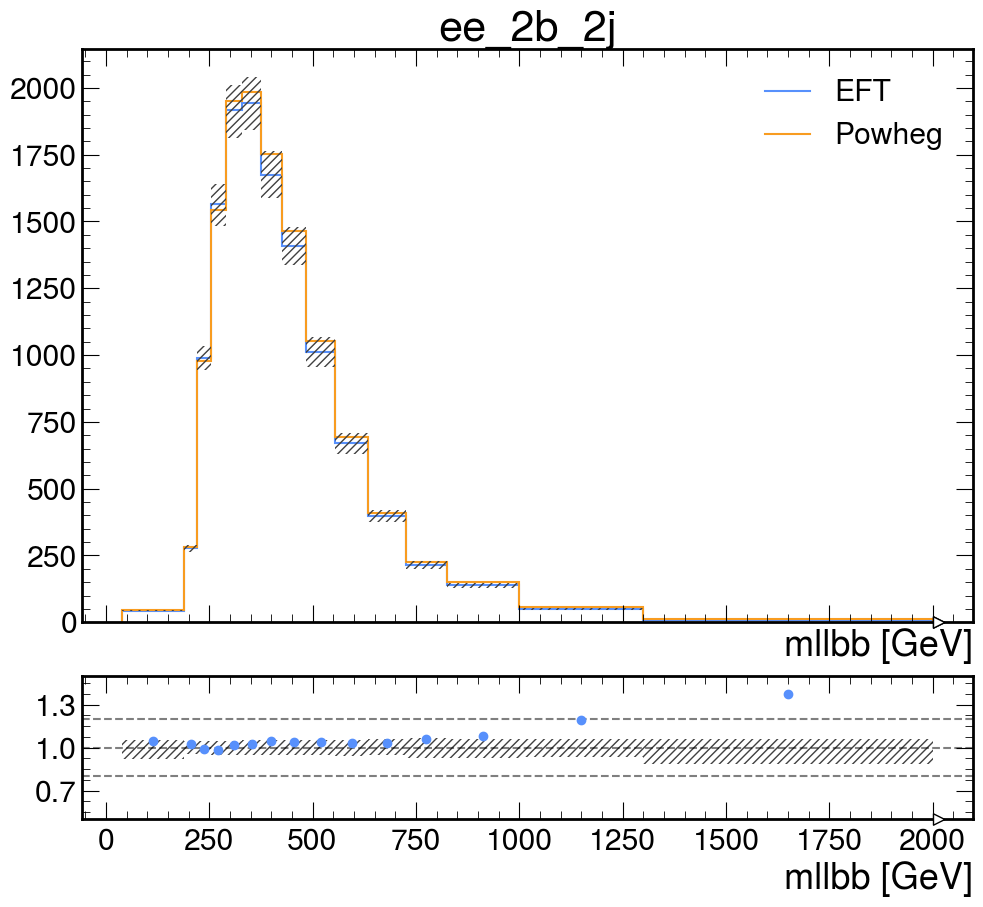

plot saved to LOtoNLOuncert_plots/ee_2b_2j_uncorrected.png


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


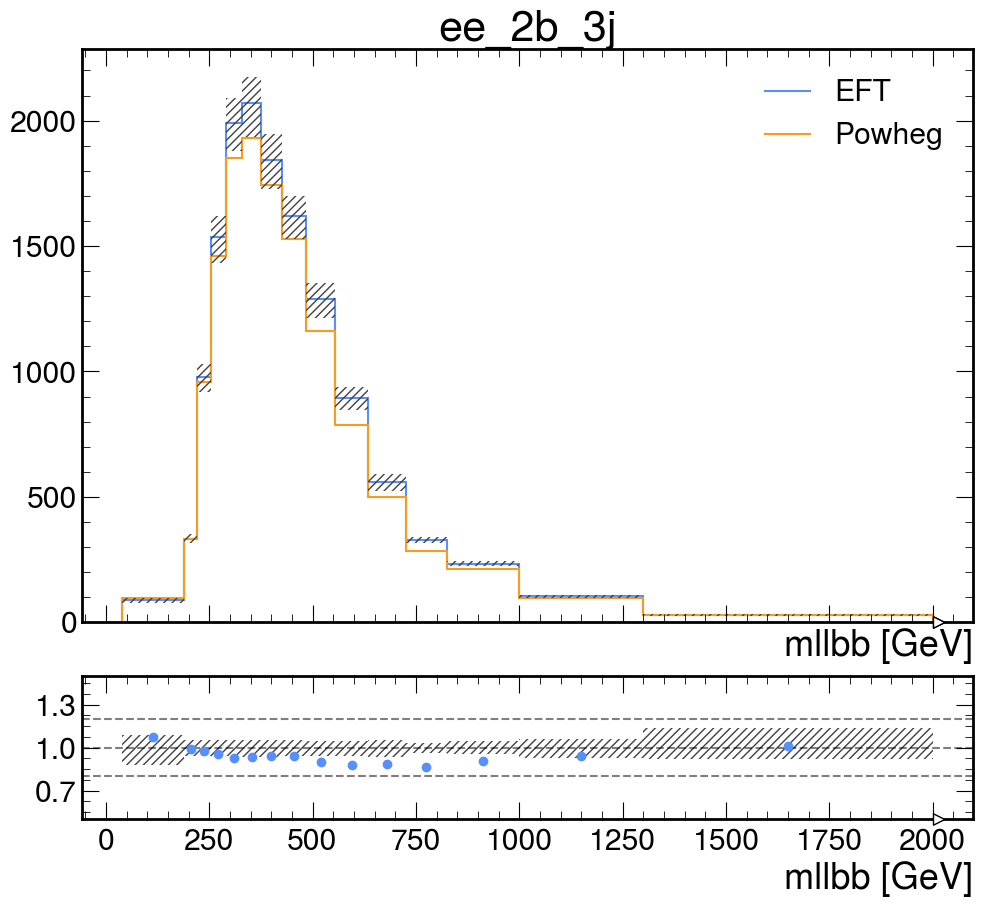

plot saved to LOtoNLOuncert_plots/ee_2b_3j_uncorrected.png


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


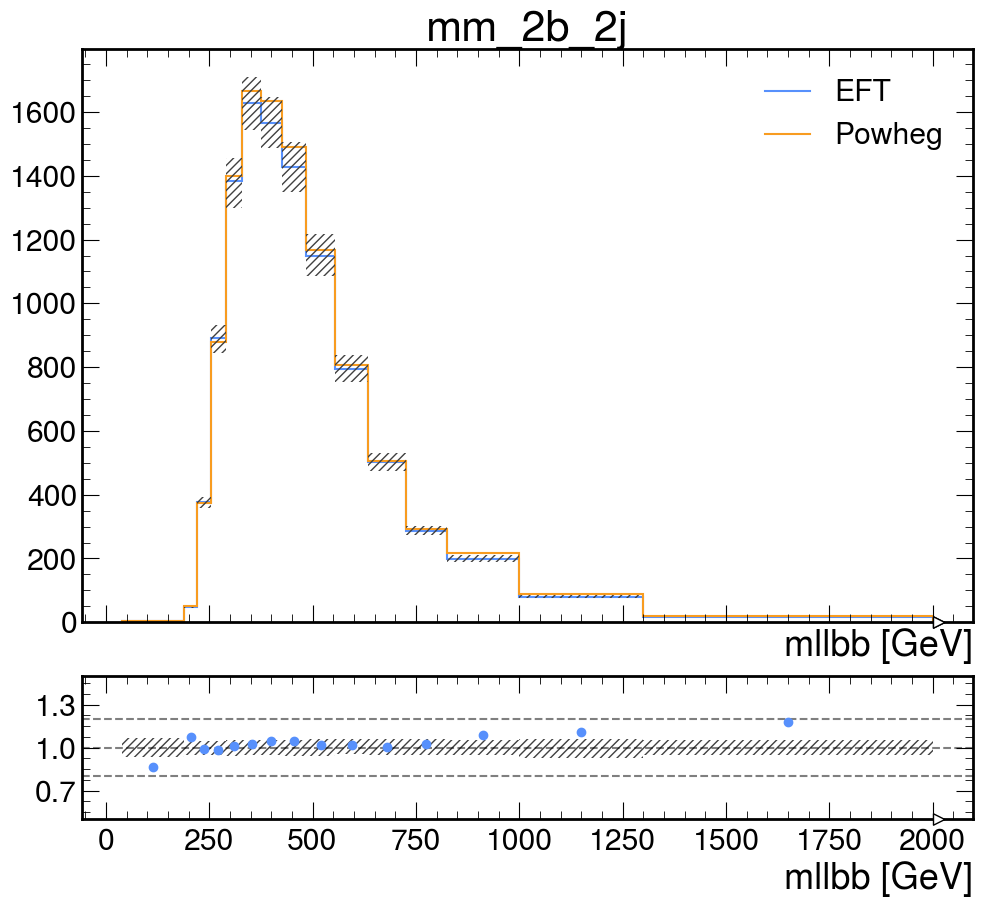

plot saved to LOtoNLOuncert_plots/mm_2b_2j_uncorrected.png


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


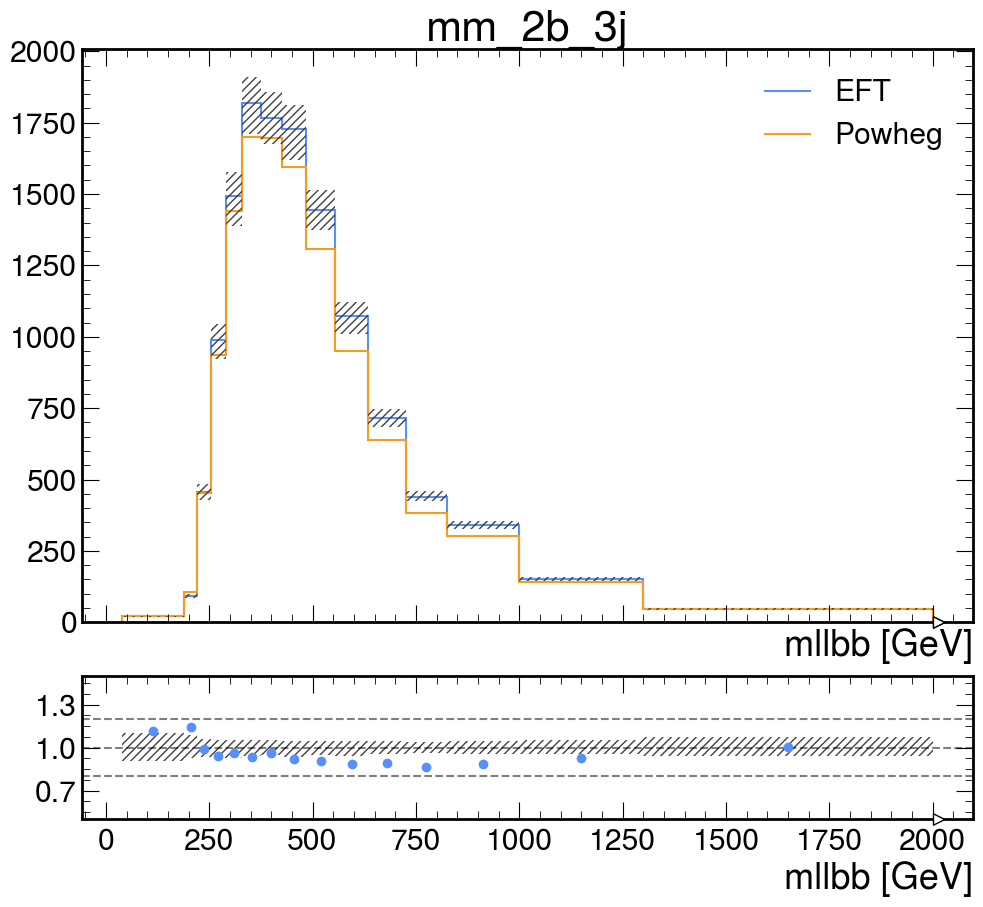

plot saved to LOtoNLOuncert_plots/mm_2b_3j_uncorrected.png


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


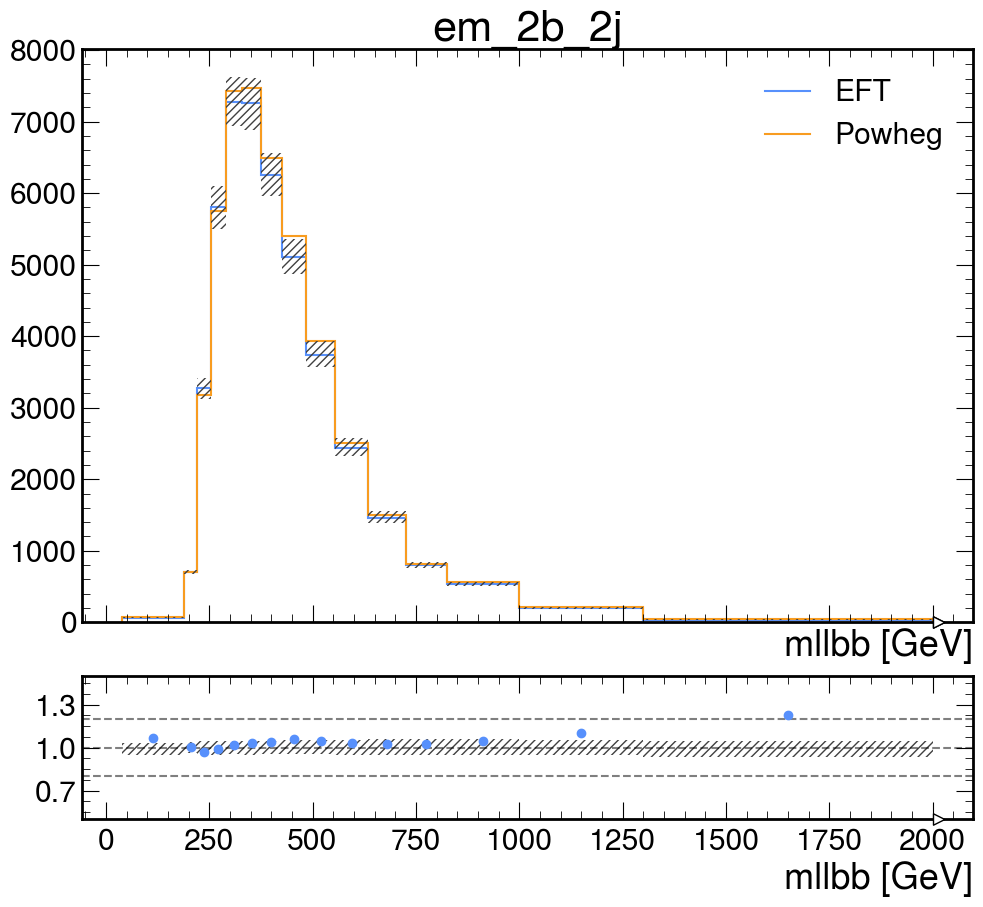

plot saved to LOtoNLOuncert_plots/em_2b_2j_uncorrected.png


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


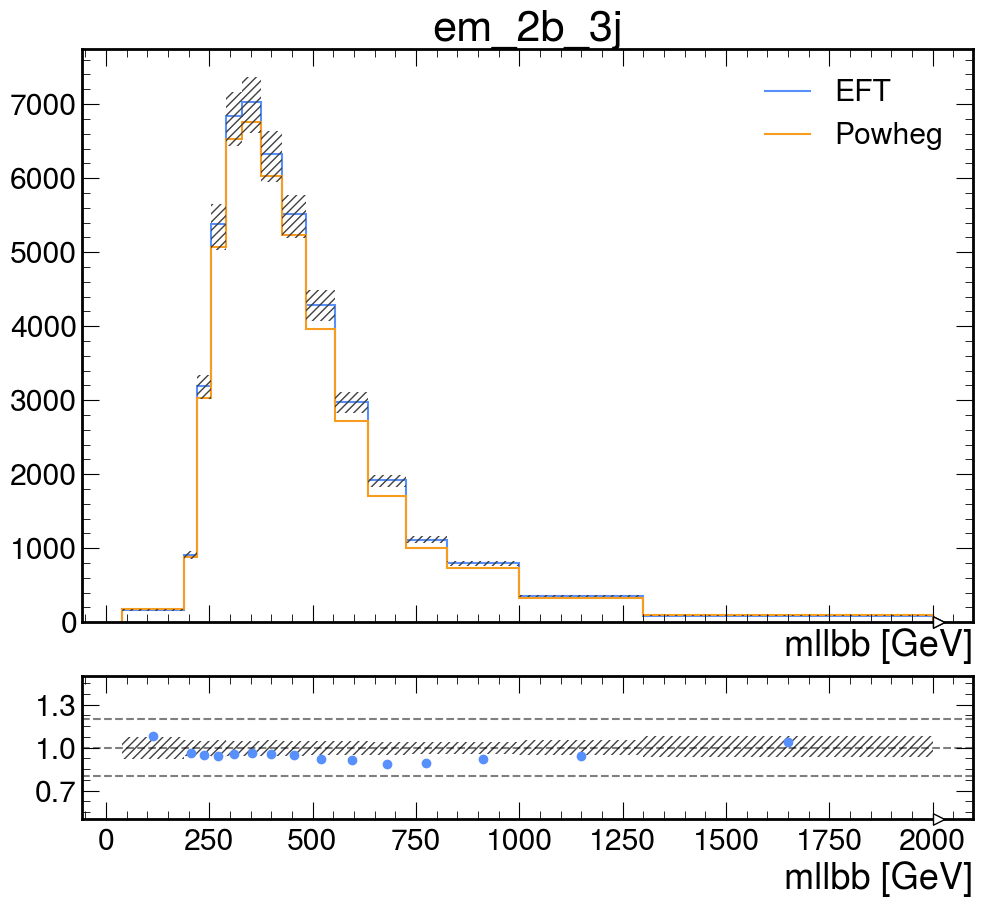

plot saved to LOtoNLOuncert_plots/em_2b_3j_uncorrected.png


In [11]:
var = 'mllbb'
outfile = "powheg_match_uncertainties.json"
if os.path.exists(outfile):
    with open(outfile) as f:
        all_unc = json.load(f)
else:
    all_unc = {}
    
if var not in all_unc:
    all_unc[var] = {}

for d in hists_EFT.keys():
    h_EFTbase = hists_EFT[d][var]
    h_Powhegbase = hists_powheg[d][var]
    EFT_tt_procs = [x for x in list(h_EFTbase.axes['process']) if 'TT01j2l' in x]
    Powheg_tt_procs = [x for x in list(h_Powhegbase.axes['process']) if 'TTTo' in x]
    channels = list(h_EFTbase.axes['channel'])
    theory_systs = ['hdamp', 'FSR', 'ISR', 'renorm', 'fact', 'PDF']

    h_PDFweights_EFT = hists_EFT[d]['LHEPDFweights']# [{'channel':ch}]
    
    for ch in channels: 
        EFT_syst = h_EFTbase[{'channel':ch, 'process':EFT_tt_procs}].as_hist({})
        POW_nom = h_Powhegbase[{'systematic':'nominal', 'channel':channel_conversion[ch], 'process':Powheg_tt_procs}][{'process':sum, 'channel':sum}].as_hist({})
        EFT_nom = h_EFTbase[{'systematic':'nominal', 'channel':ch, 'process':EFT_tt_procs}][{'process':sum}].as_hist({})
        
        h_PDFweights_EFT_ch = h_PDFweights_EFT[{'channel':ch}]
        
        EFT_shape_systs_summed_arr_m , EFT_shape_systs_summed_arr_p = get_shape_syst_arrs(EFT_syst, syst_var_lst=theory_systs, PDF_var_histo=h_PDFweights_EFT_ch)
        nom_arr_all = EFT_nom.values()
        p_err_arr = nom_arr_all + np.sqrt(EFT_shape_systs_summed_arr_p)
        m_err_arr = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m)    
        
#         POW_arr_all = POW_nom.values()
#         total_distance_squared = (POW_arr_all - nom_arr_all) ** 2
#         powheg_is_above = (POW_arr_all >= nom_arr_all)
#         missing_variance_p = np.where(
#             powheg_is_above, 
#             np.maximum(0.0, total_distance_squared - EFT_shape_systs_summed_arr_p), 
#             0.0
#         )
#         missing_variance_m = np.where(
#             ~powheg_is_above, 
#             np.maximum(0.0, total_distance_squared - EFT_shape_systs_summed_arr_m), 
#             0.0
#         )
        
#         print(f"miss var p : {np.sqrt(missing_variance_p)}")
#         print(f"miss var m : {np.sqrt(missing_variance_m)}")
        
#         p_err_arr = nom_arr_all + np.sqrt(EFT_shape_systs_summed_arr_p+missing_variance_p)
#         m_err_arr = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m+missing_variance_m)
        
        hep.style.use("CMS")
        fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(11.5,10),                                        # figsize=(10,12), # figsize=(11.5,10), figsize =(10, 10)
            gridspec_kw={'height_ratios': (4, 1), 'hspace':0.15},     # gridspec_kw={'height_ratios': (3, 1), 'hspace':0.05},
            sharex=True
        )

        hep.histplot(
            EFT_nom,
            stack=True,
            histtype="step",
            yerr=False,
            label=f"EFT",
            ax=ax
        )
        
        hep.histplot(
            POW_nom,
            stack=True,
            histtype="step",
            yerr=False,
            label=f"Powheg",
            ax=ax
        )
        
        ratio = POW_nom/EFT_nom 
        hep.histplot(
            ratio, 
            histtype='errorbar',
            markersize=12,
            ax=rax
        )
        
        
        mc_vals = EFT_nom.values()
        bin_edges = np.asarray(EFT_nom.axes.edges[0])
        bin_centers = EFT_nom.axes.centers

        ### add syst uncertainty band to main plot ###
        p_err_arr = np.where(mc_vals>0,p_err_arr,0)
        m_err_arr = np.where(mc_vals>0,m_err_arr,0)

        ax.fill_between(
            bin_edges, 
            np.append(m_err_arr, m_err_arr[-1]),
            np.append(p_err_arr, p_err_arr[-1]),
            # step='post', 
            # hatch='\\\\\\\\\\',
            # alpha=0.5,
            step='post', 
            hatch='////',
            edgecolor= '#404040',# 'dimgray',  
            facecolor='none',
            linewidth=0,
        )

        ### add syst uncertainty band to ratio plot ###
        p_err_arr_ratio = np.where(mc_vals>0,p_err_arr/mc_vals,1)
        m_err_arr_ratio = np.where(mc_vals>0,m_err_arr/mc_vals,1)

        rax.fill_between(
            bin_edges, 
            np.append(m_err_arr_ratio, m_err_arr_ratio[-1]), 
            np.append(p_err_arr_ratio, p_err_arr_ratio[-1]), 
            # step='post', 
            # hatch='\\\\\\\\\\',
            # # color='dimgrey',
            # alpha=0.1, 
            step='post', 
            hatch='////', # hatch='\\\\\\\\\\',
            # alpha=0.1, 
            edgecolor= '#404040',# 'dimgray',  
            facecolor='none',
            linewidth=0,
        )

        rax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
        rax.axhline(y=0.8, color='black', linestyle='--', alpha=0.5)
        rax.axhline(y=1.2, color='black', linestyle='--', alpha=0.5)
        rax.set_ylim([0.5, 1.5])                    # rax.set_ylim([0.5, 1.5])
        rax.set_yticks([0.7, 1.0, 1.3])             # rax.set_yticks([0.8, 1.0, 1.2, 1.4]) 

        ax.legend()
        ax.set_title(f"{ch}")
        plt.show()
        
        save_figure(fig, f"{ch}_uncorrected", outdir='LOtoNLOuncert_plots/')

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


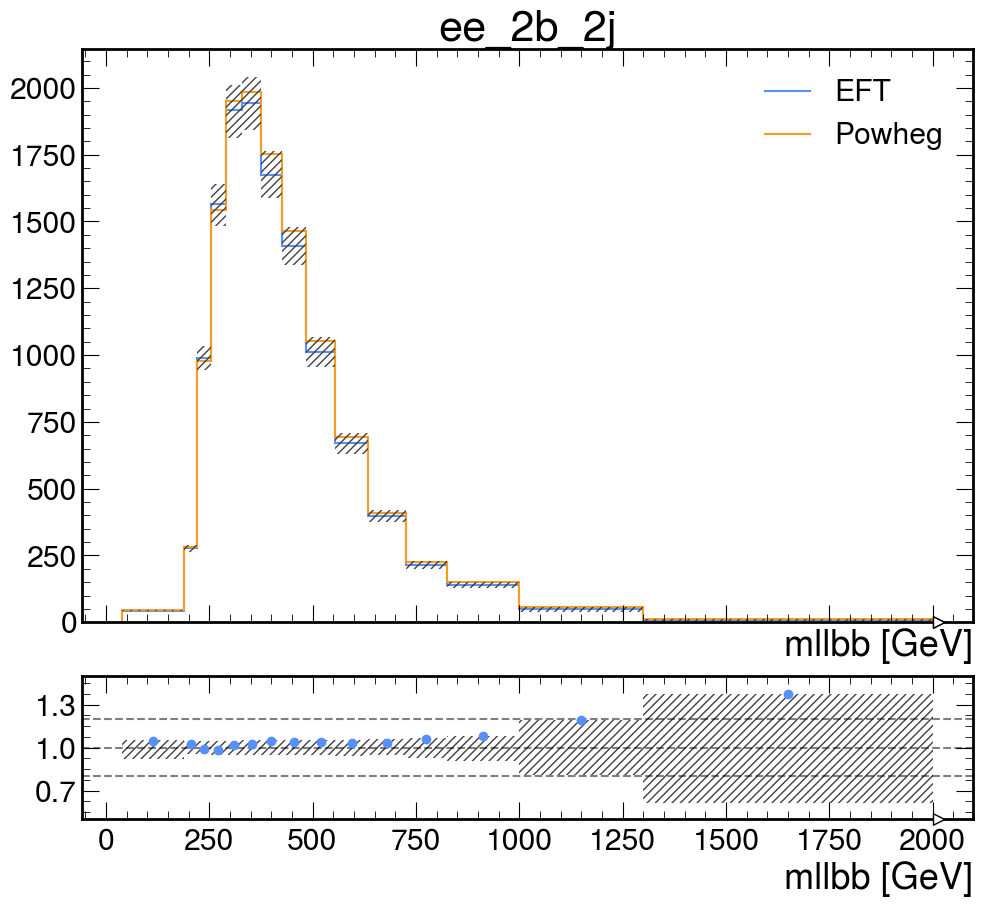

plot saved to LOtoNLOuncert_plots/ee_2b_2j_corrected.png
plus: [  43.90427757  276.32793768  989.7381868  1564.99218977 1917.91770415
 1942.16377735 1675.41147363 1408.6410329  1010.96801983  670.28529729
  396.32845684  214.02931     147.50713878   58.21199522   12.68293468]
minus: [  43.90427757  276.32793768  989.7381868  1564.99218977 1917.91770415
 1942.16377735 1675.41147363 1408.6410329  1010.96801983  670.28529729
  396.32845684  214.02931     132.66386679   40.46173655    5.82629219]


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


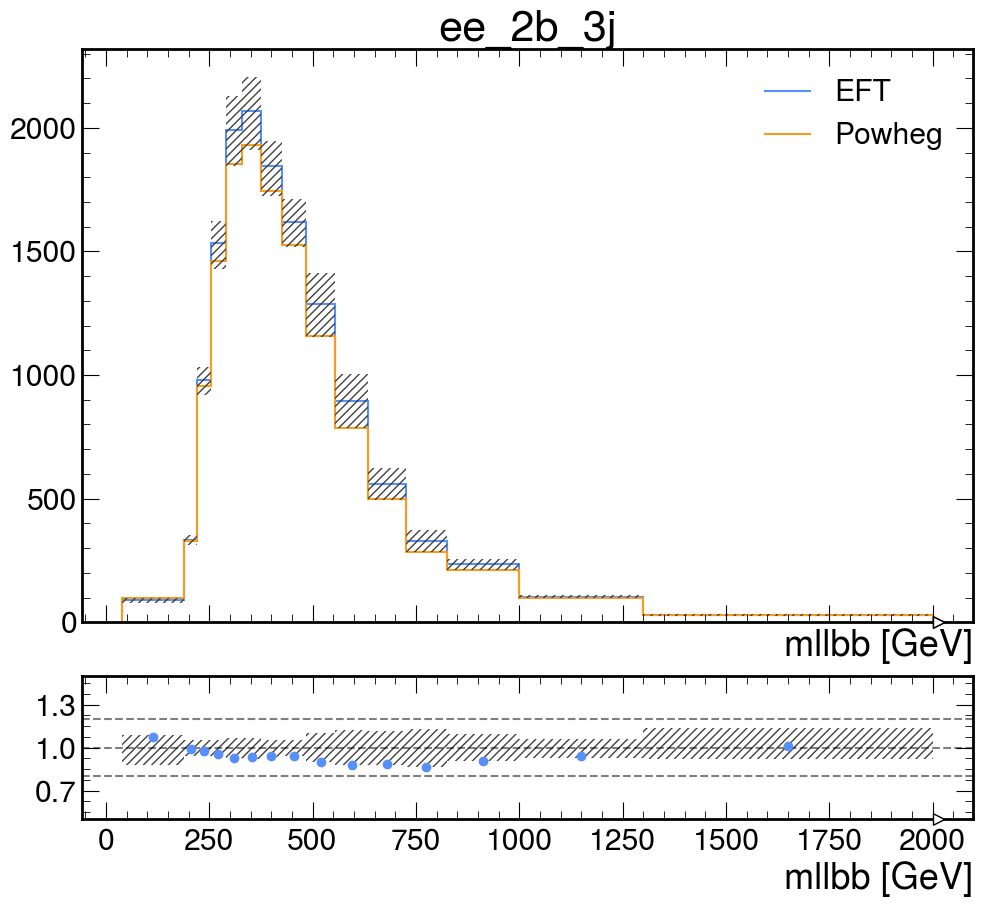

plot saved to LOtoNLOuncert_plots/ee_2b_3j_corrected.png
plus: [  89.28638263  333.84387277  979.27109594 1535.58421599 2088.02049552
 2157.20414074 1858.49593135 1658.50667367 1397.27523238  994.38898966
  616.51217838  370.51565356  253.10672366  103.69651996   27.8829704 ]
minus: [  89.28638263  333.84387277  979.27109594 1535.58421599 1893.97578751
 1982.24100744 1830.34884811 1579.29249397 1176.75732308  796.07471897
  504.79584656  286.70624761  214.85154696  103.69651996   27.8829704 ]


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


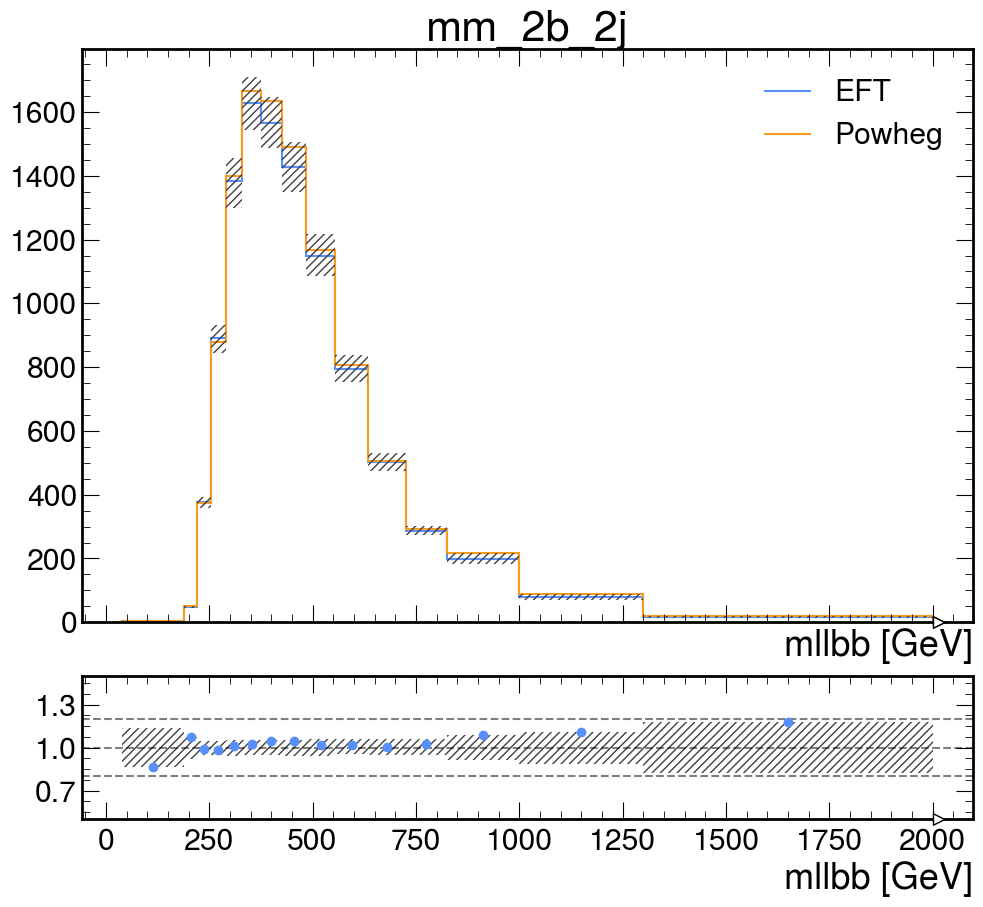

plot saved to LOtoNLOuncert_plots/mm_2b_2j_corrected.png
plus: [   3.80515952   50.45601514  376.44970173  891.0823822  1383.59520804
 1627.17940794 1565.37511907 1427.37563    1149.79592558  792.79870402
  501.10340946  285.93517993  212.54830375   87.96440899   18.93131168]
minus: [   2.9756924    44.68362342  376.44970173  891.0823822  1383.59520804
 1627.17940794 1565.37511907 1427.37563    1149.79592558  792.79870402
  501.10340946  285.93517993  185.00939337   73.41467684   13.42206726]


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


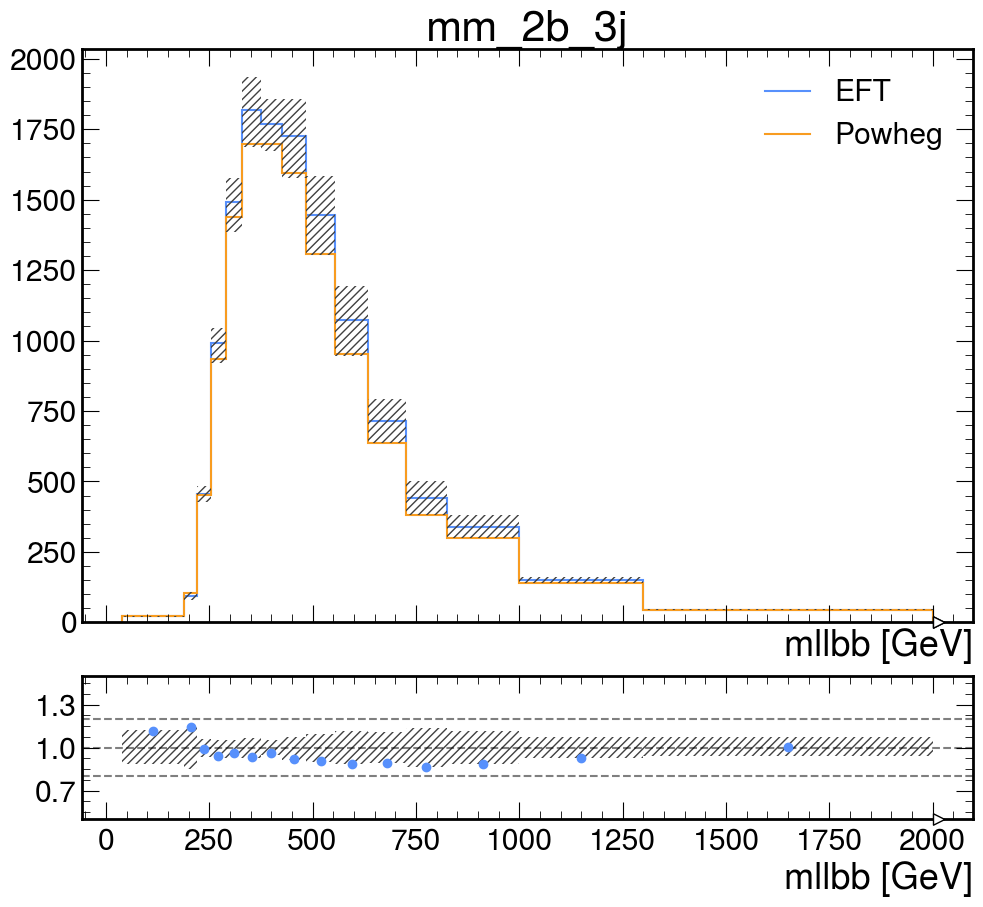

plot saved to LOtoNLOuncert_plots/mm_2b_3j_corrected.png
plus: [  22.03481101  103.50315042  456.38002769  998.00544417 1493.27319812
 1891.73963725 1767.64471078 1828.47736712 1566.2971723  1182.49291842
  786.72829405  497.04050463  376.64210853  159.32482424   45.13075567]
minus: [  19.29284258   80.49482262  456.38002769  982.49094191 1493.27319812
 1743.72692265 1767.64471078 1625.16289516 1324.83703925  961.86432483
  644.24585343  383.85144362  303.25480297  142.1560334    45.13075567]


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


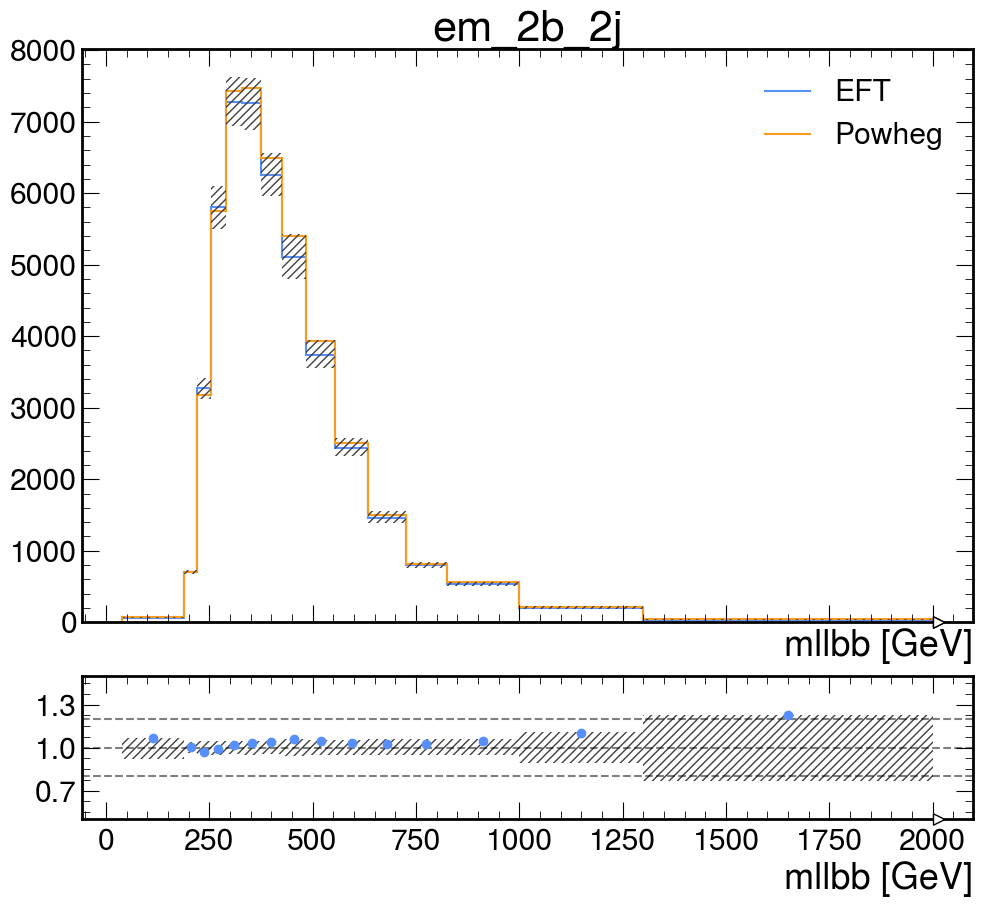

plot saved to LOtoNLOuncert_plots/em_2b_2j_corrected.png
plus: [  69.83275793  698.46359516 3274.64041349 5806.39038892 7279.09210794
 7253.86491766 6250.33928197 5284.45193241 3810.65152219 2440.37614406
 1463.86440044  800.47559906  530.79663527  218.13569696   47.44902261]
minus: [  61.75123149  698.46359516 3274.64041349 5806.39038892 7279.09210794
 7253.86491766 6250.33928197 4920.25413193 3671.73599679 2440.37614406
 1463.86440044  800.47559906  530.79663527  181.30727134   30.13317514]


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


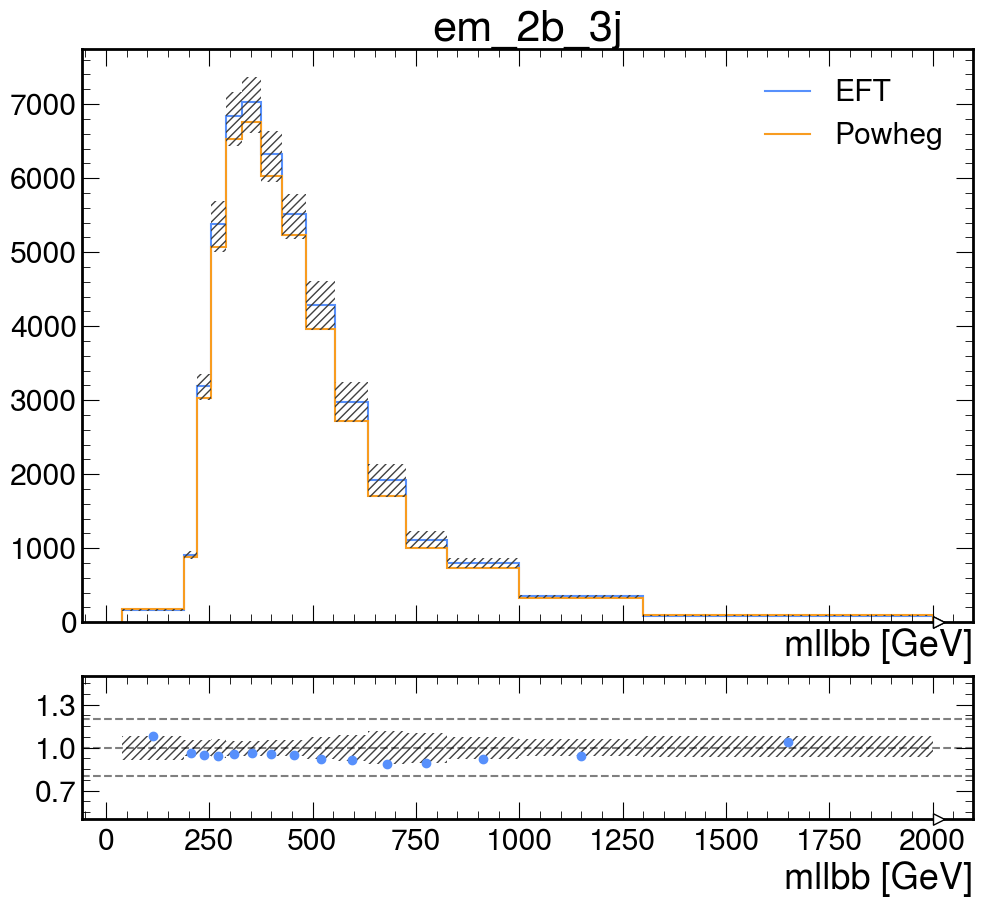

plot saved to LOtoNLOuncert_plots/em_2b_3j_corrected.png
plus: [ 169.19888457  908.27281374 3228.39153881 5529.45138031 6833.95236224
 7026.88639692 6324.58223129 5607.27524632 4546.23179673 3212.71687772
 2119.52104067 1224.14413151  852.89201649  362.73513364   91.48224884]
minus: [ 159.34612906  908.27281374 3150.92526234 5226.76821112 6833.95236224
 7026.88639692 6324.58223129 5410.23218685 4025.03685226 2746.33935819
 1715.66277377 1009.79351554  748.6442583   342.833058     91.48224884]
Updated powheg_match_uncertainties.json


In [21]:
var = 'mllbb'
outfile = "powheg_match_uncertainties.json"
if os.path.exists(outfile):
    with open(outfile) as f:
        all_unc = json.load(f)
else:
    all_unc = {}
    
if var not in all_unc:
    all_unc[var] = {}

for d in hists_EFT.keys():
    h_EFTbase = hists_EFT[d][var]
    h_Powhegbase = hists_powheg[d][var]
    EFT_tt_procs = [x for x in list(h_EFTbase.axes['process']) if 'TT01j2l' in x]
    Powheg_tt_procs = [x for x in list(h_Powhegbase.axes['process']) if 'TTTo' in x]
    channels = list(h_EFTbase.axes['channel'])
    theory_systs = ['hdamp', 'FSR', 'ISR', 'renorm', 'fact', 'PDF']

    h_PDFweights_EFT = hists_EFT[d]['LHEPDFweights']# [{'channel':ch}]
    
    for ch in channels: 
        EFT_syst = h_EFTbase[{'channel':ch, 'process':EFT_tt_procs}].as_hist({})
        POW_nom = h_Powhegbase[{'systematic':'nominal', 'channel':channel_conversion[ch], 'process':Powheg_tt_procs}][{'process':sum, 'channel':sum}].as_hist({})
        EFT_nom = h_EFTbase[{'systematic':'nominal', 'channel':ch, 'process':EFT_tt_procs}][{'process':sum}].as_hist({})
        
        h_PDFweights_EFT_ch = h_PDFweights_EFT[{'channel':ch}]
        
        EFT_shape_systs_summed_arr_m , EFT_shape_systs_summed_arr_p = get_shape_syst_arrs(EFT_syst, syst_var_lst=theory_systs, PDF_var_histo=h_PDFweights_EFT_ch)
        nom_arr_all = EFT_nom.values()
        p_err_arr = nom_arr_all + np.sqrt(EFT_shape_systs_summed_arr_p)
        m_err_arr = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m)    
        
        POW_arr_all = POW_nom.values()
        total_distance_squared = (POW_arr_all - nom_arr_all) ** 2
        # powheg_is_above = (POW_arr_all >= nom_arr_all)
        
        needed_variance_if_above = total_distance_squared - EFT_shape_systs_summed_arr_p
        needed_variance_if_below = total_distance_squared - EFT_shape_systs_summed_arr_m
        
        missing_variance = np.maximum(
            0.0, 
            np.maximum(needed_variance_if_above, needed_variance_if_below)
        )
        
        # missing_variance_p = np.where(
        #     powheg_is_above, 
        #     np.maximum(0.0, total_distance_squared - EFT_shape_systs_summed_arr_p), 
        #     0.0
        # )
        # missing_variance_m = np.where(
        #     ~powheg_is_above, 
        #     np.maximum(0.0, total_distance_squared - EFT_shape_systs_summed_arr_m), 
        #     0.0
        # )
        
        p_err_arr = nom_arr_all + np.sqrt(EFT_shape_systs_summed_arr_p+missing_variance)
        m_err_arr = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m+missing_variance)
        
        fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(11.5,10),                                        # figsize=(10,12), # figsize=(11.5,10), figsize =(10, 10)
            gridspec_kw={'height_ratios': (4, 1), 'hspace':0.15},     # gridspec_kw={'height_ratios': (3, 1), 'hspace':0.05},
            sharex=True
        )

        hep.style.use("CMS")

        hep.histplot(
            EFT_nom,
            stack=True,
            histtype="step",
            yerr=False,
            label=f"EFT",
            ax=ax
        )
        
        hep.histplot(
            POW_nom,
            stack=True,
            histtype="step",
            yerr=False,
            label=f"Powheg",
            ax=ax
        )
        
        ratio = POW_nom/EFT_nom 
        hep.histplot(
            ratio, 
            histtype='errorbar',
            markersize=12,
            ax=rax
        )
        
        
        mc_vals = EFT_nom.values()
        bin_edges = np.asarray(EFT_nom.axes.edges[0])
        bin_centers = EFT_nom.axes.centers

        ### add syst uncertainty band to main plot ###
        p_err_arr = np.where(mc_vals>0,p_err_arr,0)
        m_err_arr = np.where(mc_vals>0,m_err_arr,0)

        ax.fill_between(
            bin_edges, 
            np.append(m_err_arr, m_err_arr[-1]),
            np.append(p_err_arr, p_err_arr[-1]),
            # step='post', 
            # hatch='\\\\\\\\\\',
            # alpha=0.5,
            step='post', 
            hatch='////',
            edgecolor= '#404040',# 'dimgray',  
            facecolor='none',
            linewidth=0,
        )

        ### add syst uncertainty band to ratio plot ###
        p_err_arr_ratio = np.where(mc_vals>0,p_err_arr/mc_vals,1)
        m_err_arr_ratio = np.where(mc_vals>0,m_err_arr/mc_vals,1)

        rax.fill_between(
            bin_edges, 
            np.append(m_err_arr_ratio, m_err_arr_ratio[-1]), 
            np.append(p_err_arr_ratio, p_err_arr_ratio[-1]), 
            # step='post', 
            # hatch='\\\\\\\\\\',
            # # color='dimgrey',
            # alpha=0.1, 
            step='post', 
            hatch='////', # hatch='\\\\\\\\\\',
            # alpha=0.1, 
            edgecolor= '#404040',# 'dimgray',  
            facecolor='none',
            linewidth=0,
        )

        rax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
        rax.axhline(y=0.8, color='black', linestyle='--', alpha=0.5)
        rax.axhline(y=1.2, color='black', linestyle='--', alpha=0.5)
        rax.set_ylim([0.5, 1.5])                    # rax.set_ylim([0.5, 1.5])
        rax.set_yticks([0.7, 1.0, 1.3])             # rax.set_yticks([0.8, 1.0, 1.2, 1.4]) 

        ax.legend()
        ax.set_title(f"{ch}")
        plt.show()
        
        save_figure(fig, f"{ch}_corrected", outdir='LOtoNLOuncert_plots/')

        # Extract the real native nominal array including flow bins
        # This gives an array of length 17: [underflow, bin1, ..., bin15, true_overflow]
        native_nominal_with_flow = EFT_nom.values(flow=True)
        true_overflow_val = native_nominal_with_flow[-1]
        
        p_err_arr_json = nom_arr_all + np.sqrt(missing_variance)
        m_err_arr_json = nom_arr_all - np.sqrt(missing_variance)
        
        print(f"plus: {p_err_arr_json}")
        print(f"minus: {m_err_arr_json}")

        # 3. Convert standalone physical interior calculations to lists
        p_err_list = p_err_arr_json.tolist()
        m_err_list = np.maximum(0.0, m_err_arr_json).tolist() # Floor clamp
        nom_list   = nom_arr_all.tolist()

        last_phys_nom  = nom_list[-1]
        last_phys_up   = p_err_list[-1]
        last_phys_down = m_err_list[-1]

        if last_phys_nom > 0:
            delta_up   = (last_phys_up - last_phys_nom) / last_phys_nom
            delta_down = (last_phys_nom - last_phys_down) / last_phys_nom
        else:
            delta_up   = 0.0
            delta_down = 0.0

        # 5. Fetch true nominal overflow value and apply the isolated percentage shift
        native_nominal_with_flow = EFT_nom.values(flow=True)
        true_overflow_val = native_nominal_with_flow[-1]

        overflow_up   = true_overflow_val * (1.0 + delta_up)
        overflow_down = np.maximum(0.0, true_overflow_val * (1.0 - delta_down))

        # 6. Reconstruct padded 17-length arrays for JSON export
        padded_nominal = [0.0] + nom_list + [true_overflow_val]
        padded_up      = [0.0] + p_err_list + [overflow_up]
        padded_down    = [0.0] + m_err_list + [overflow_down]
        
        all_unc[var][ch] = {
            "nominal": padded_nominal,
            "up": padded_up,
            "down": padded_down
        }
        
        # nom_arr = add_fake_flow(nom_arr_all.tolist())
        # p_err_arr = add_fake_flow((nom_arr_all + np.sqrt(missing_variance)).tolist())
        # m_err_arr = add_fake_flow(
        #     np.maximum(0.0,nom_arr_all - np.sqrt(missing_variance)).tolist())

        # all_unc[var][ch] = {
        #     "nominal": nom_arr,
        #     "up": p_err_arr,
        #     "down": m_err_arr
        # }
        
with open(outfile, "w") as f:
    json.dump(all_unc, f, indent=4)
print(f"Updated {outfile}")

# Making plots with 2j, 3j, 4j separate

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


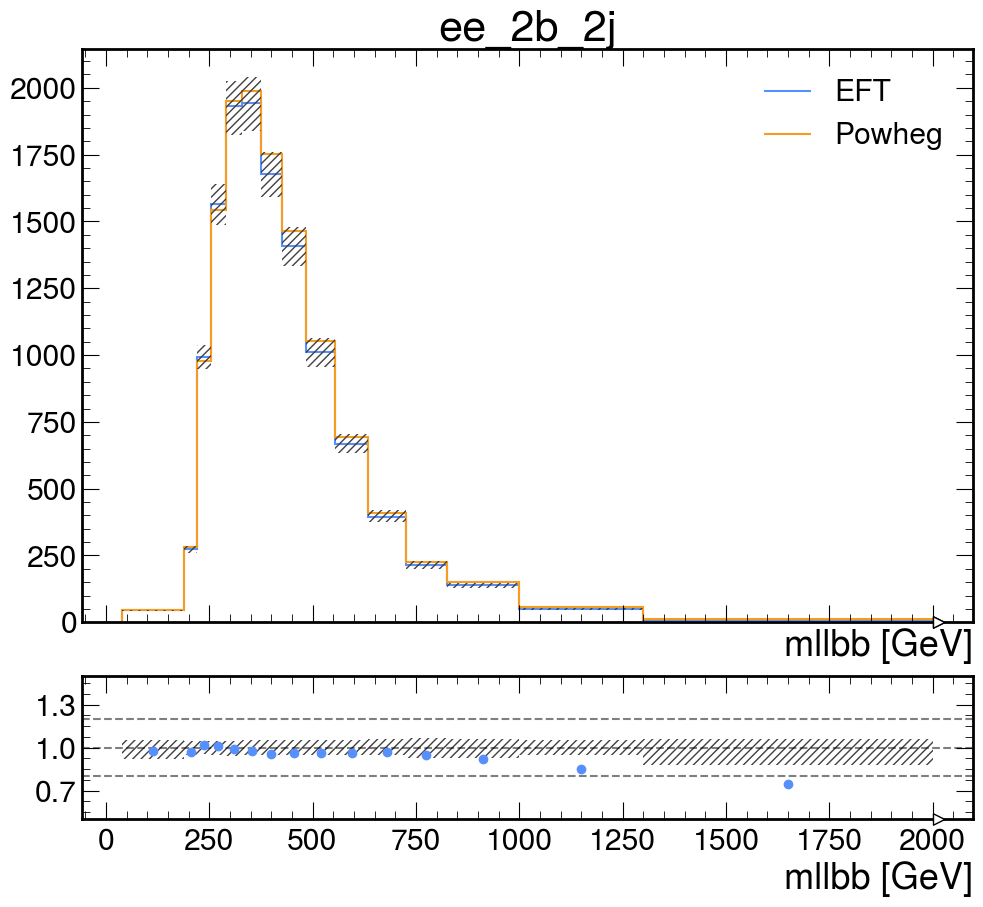

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


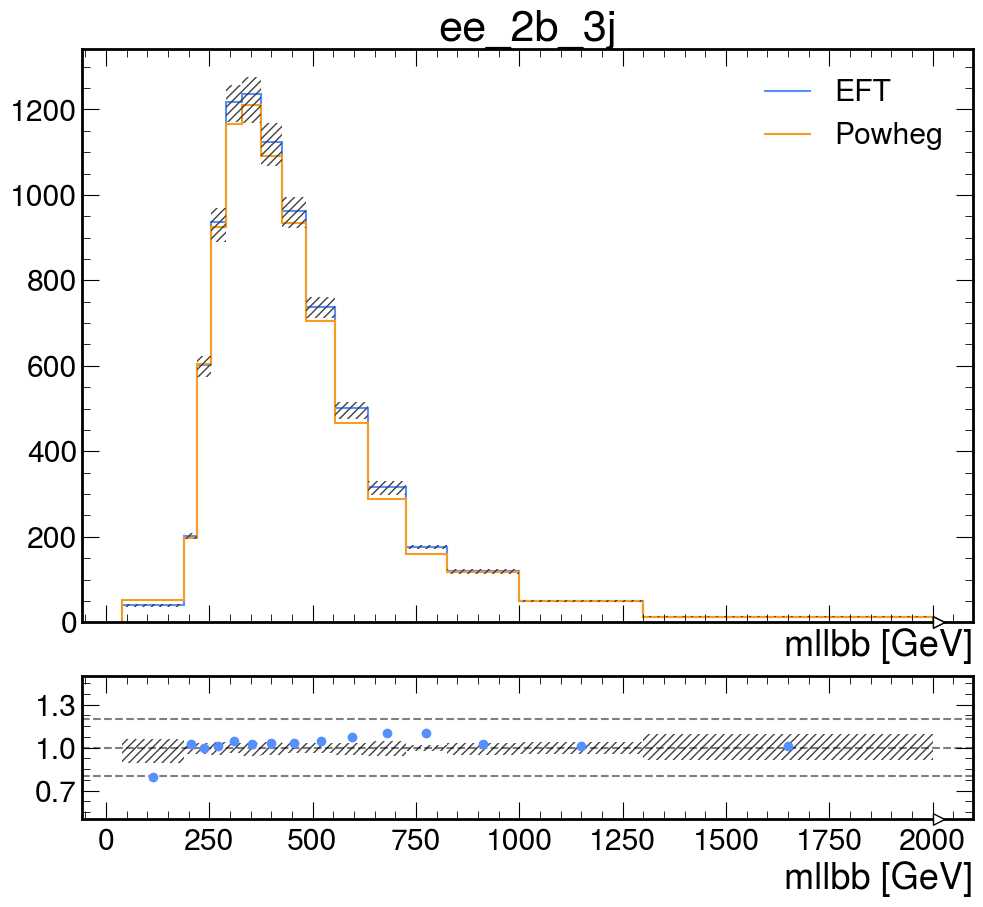

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


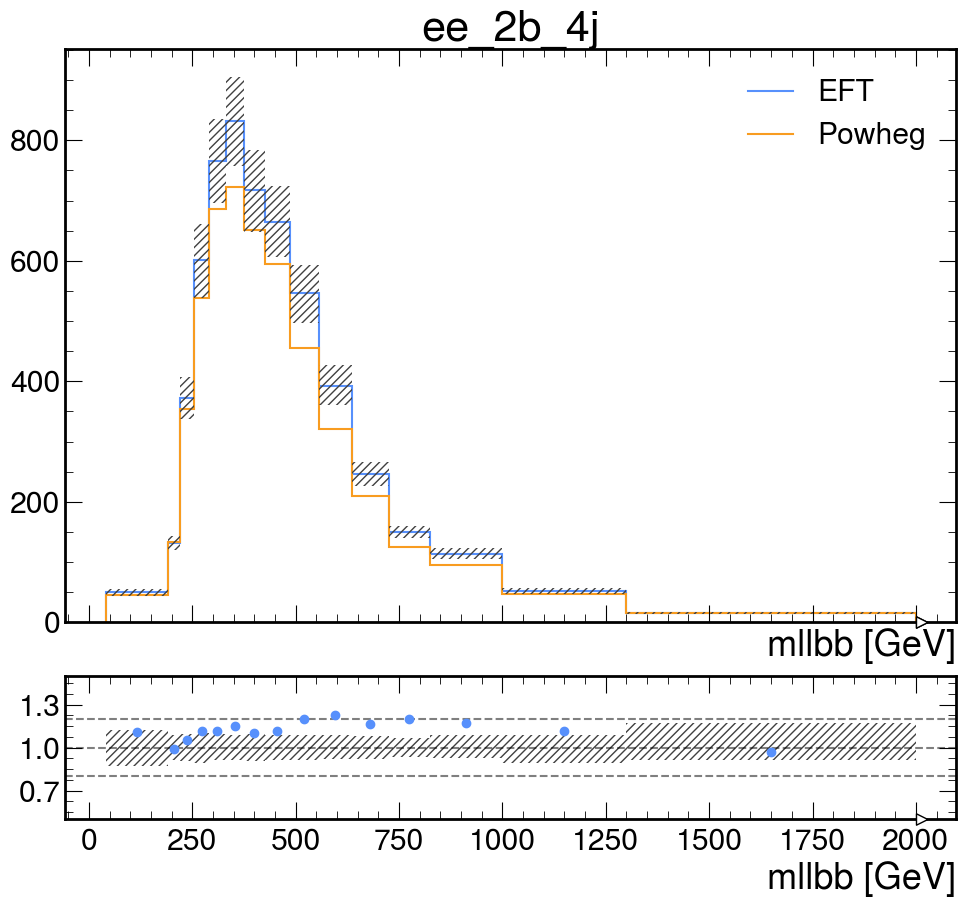

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


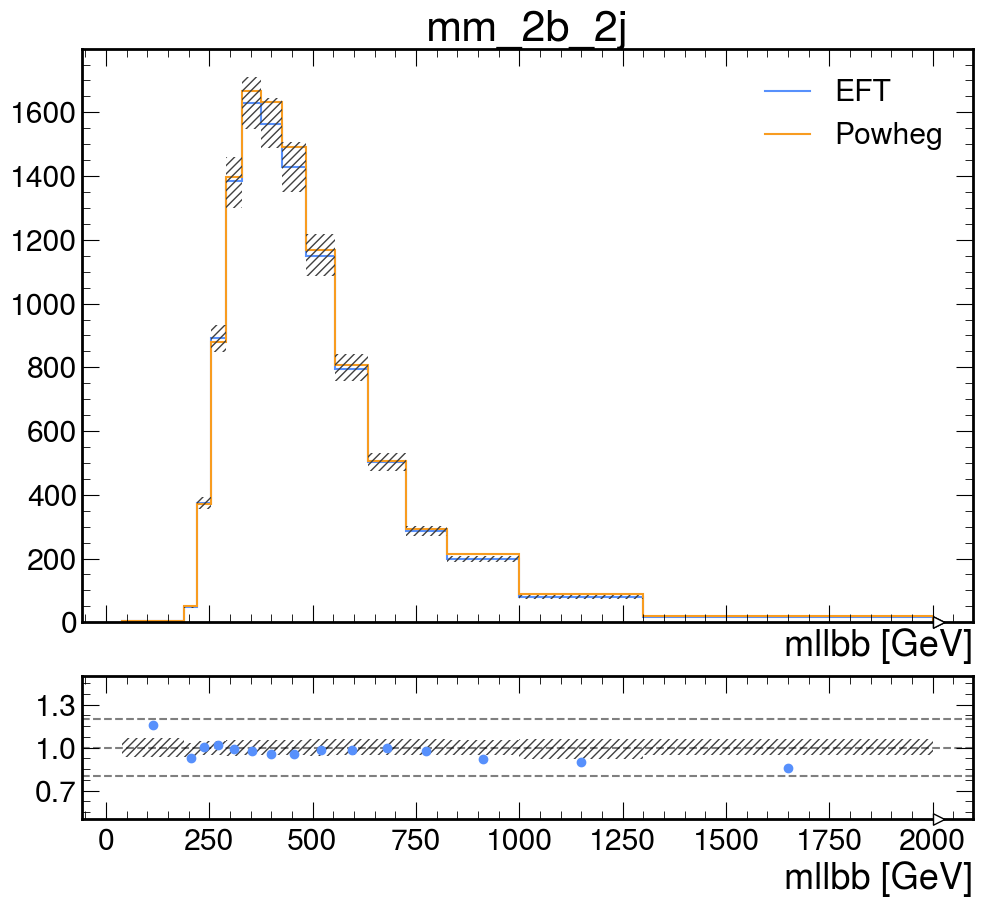

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


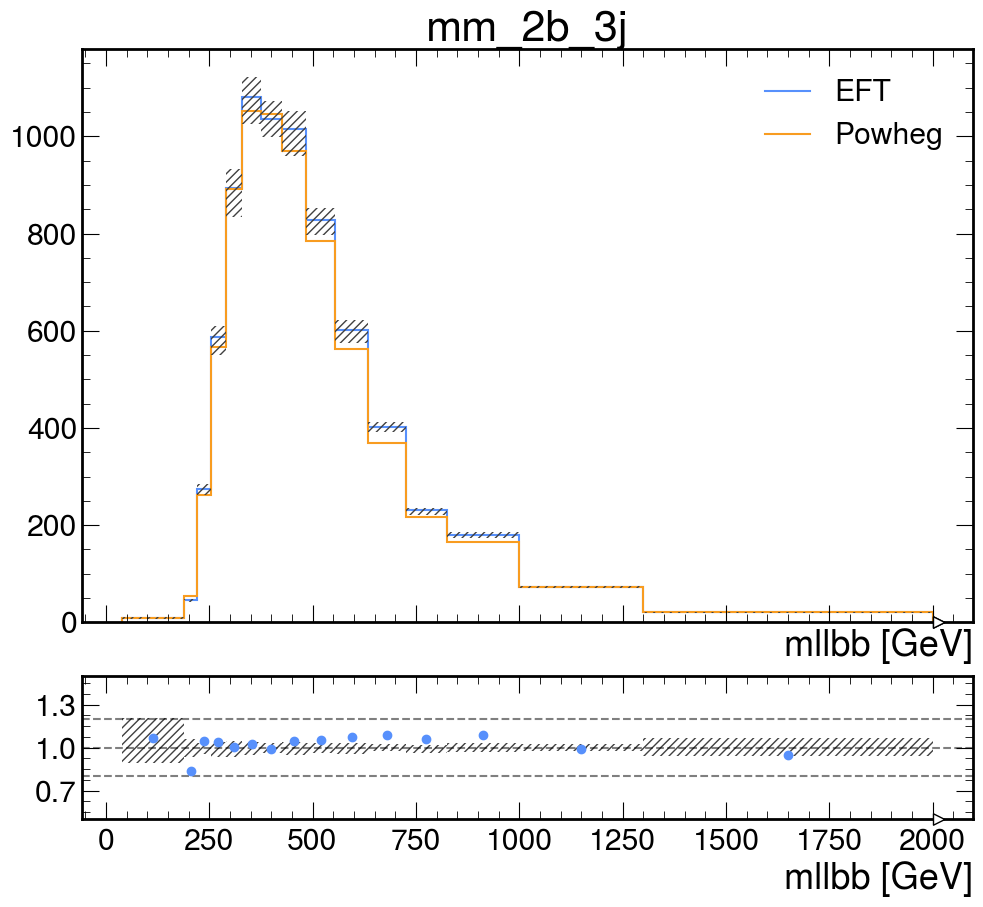

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


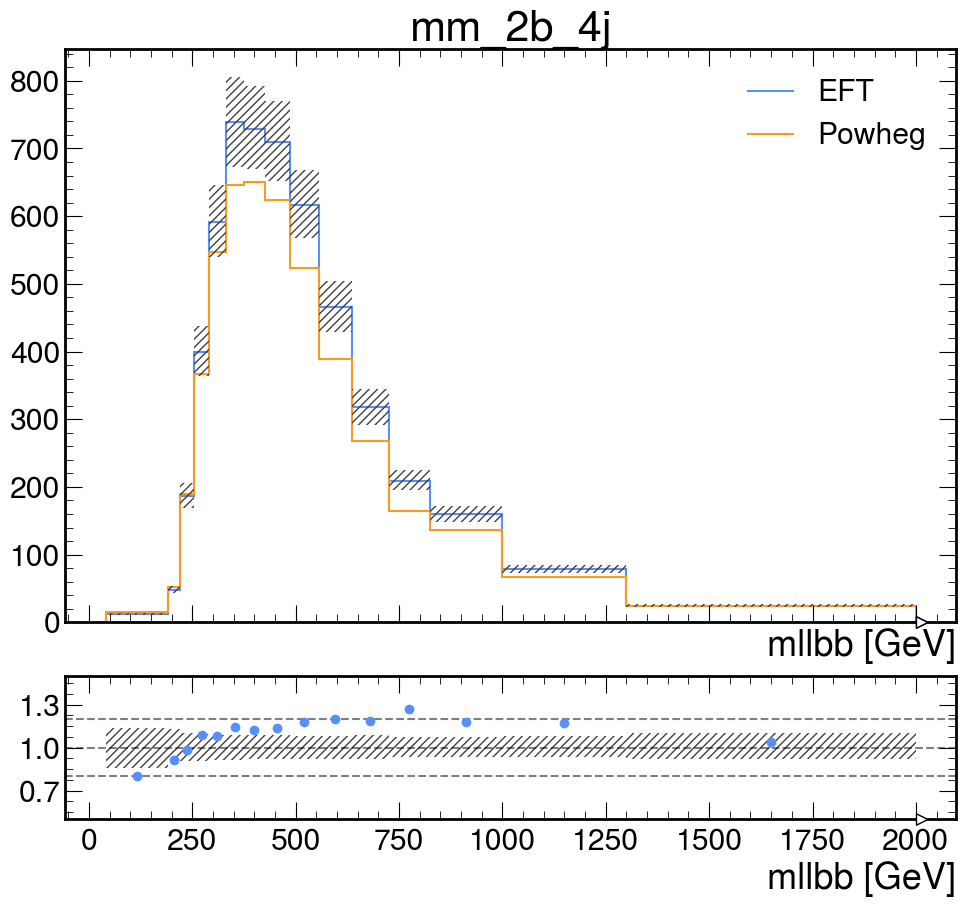

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


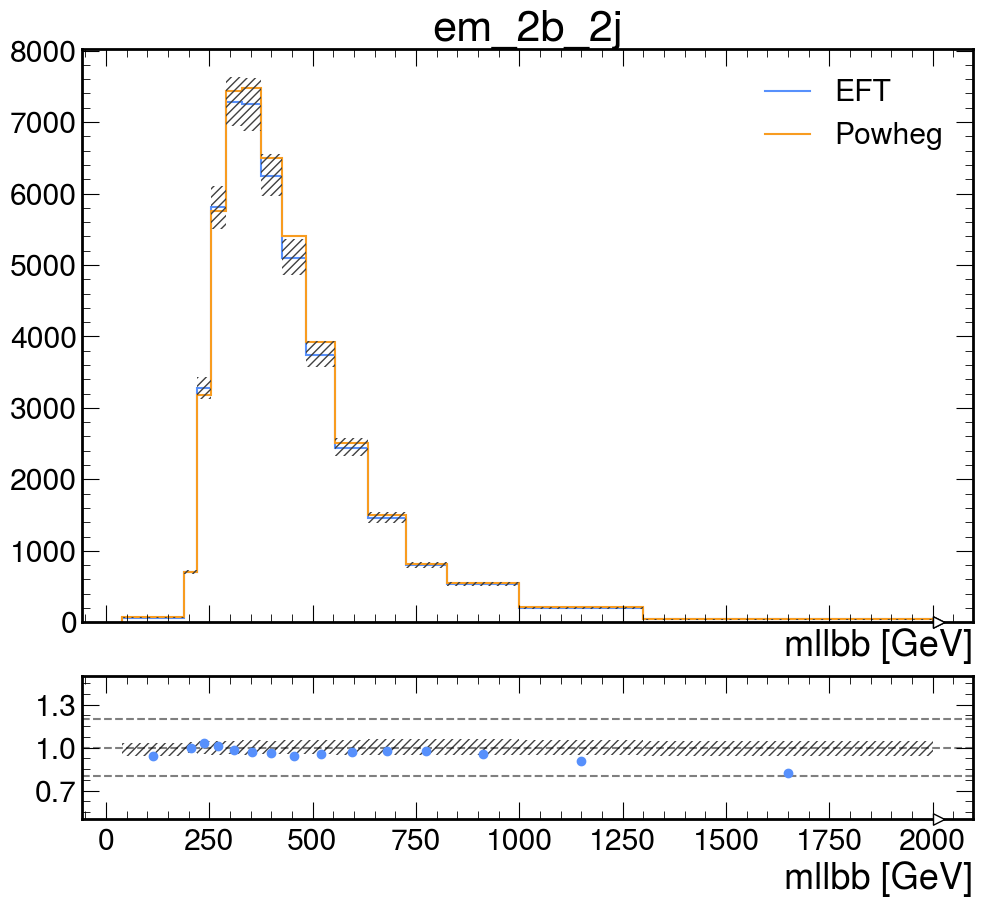

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


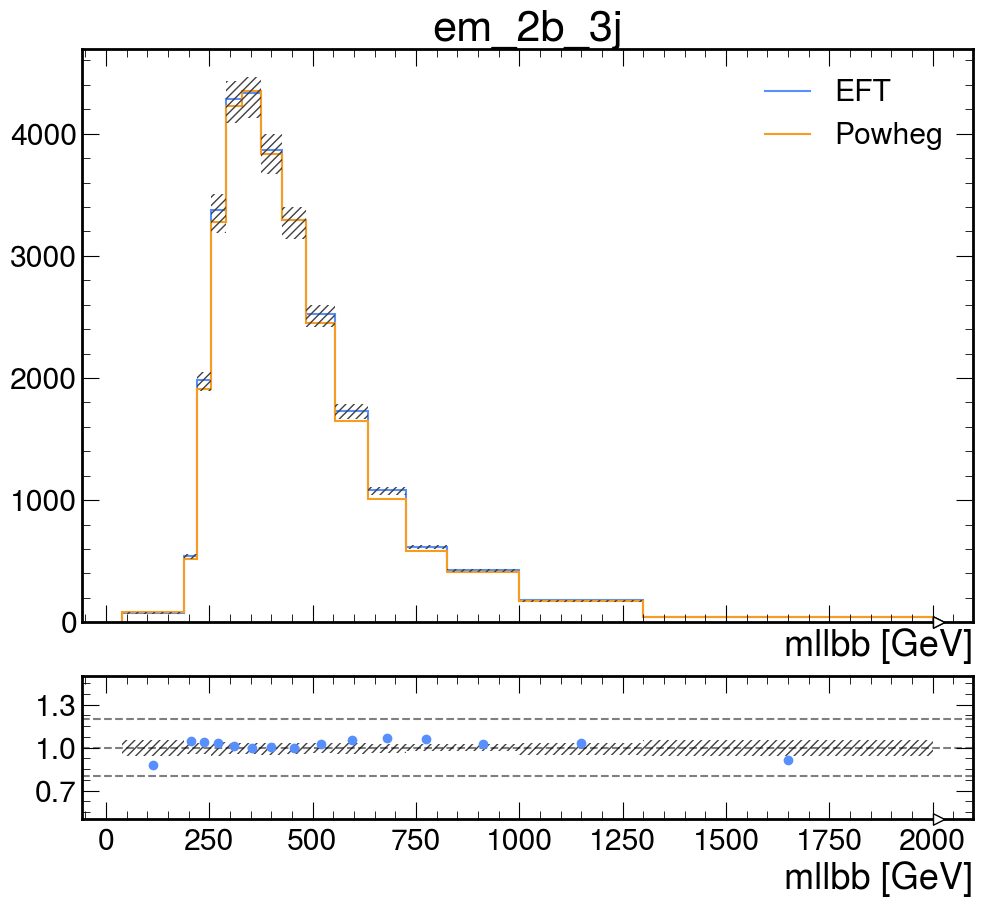

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


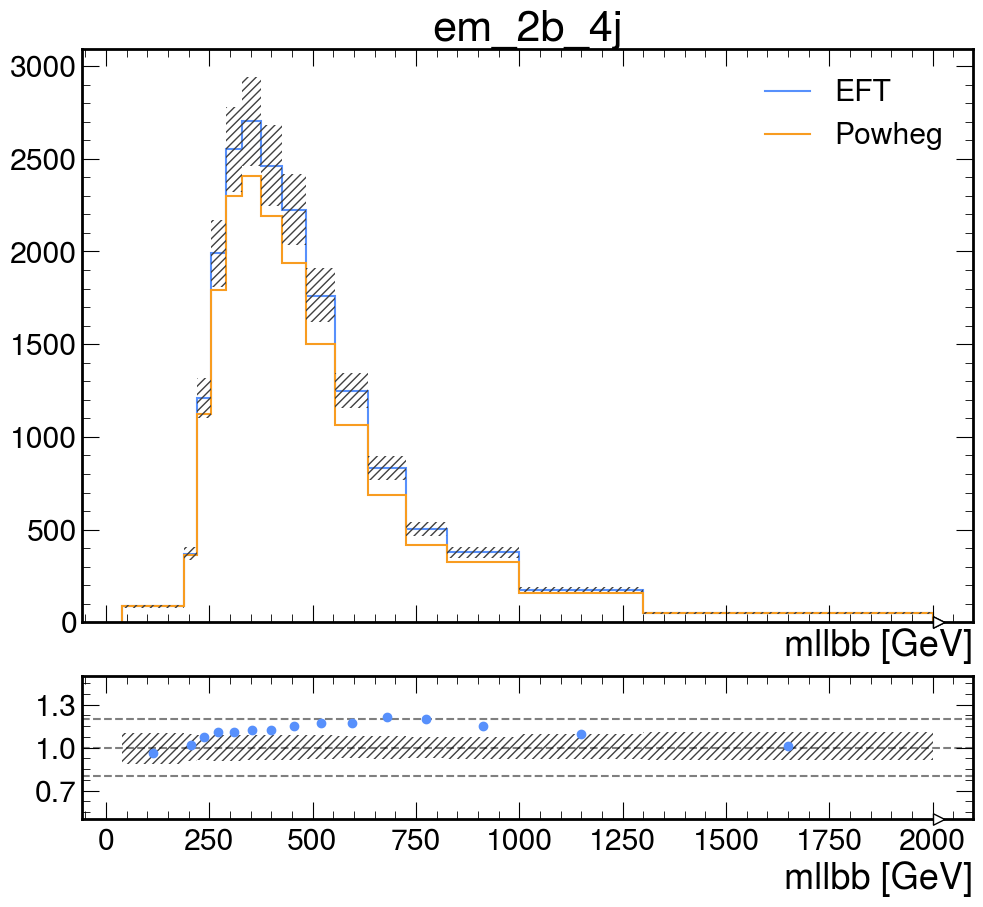

In [27]:
hists_EFT = pickle.load(gzip.open("SR_ALL_260510.pkl.gz"))
hists_powheg = pickle.load(gzip.open("SR_ALL_Powheg.pkl.gz"))

var = 'mllbb'
for d in hists_EFT.keys():
    h_EFTbase = hists_EFT[d][var]
    h_Powhegbase = hists_powheg[d][var]
    EFT_tt_procs = [x for x in list(h_EFTbase.axes['process']) if 'TT01j2l' in x]
    Powheg_tt_procs = [x for x in list(h_Powhegbase.axes['process']) if 'TTTo' in x]
    channels = list(h_EFTbase.axes['channel'])
    theory_systs = ['hdamp', 'FSR', 'ISR', 'renorm', 'fact', 'PDF']

    h_PDFweights_EFT = hists_EFT[d]['LHEPDFweights']# [{'channel':ch}]
    # h_PDFweights_POW = hists_powheg[d]['LHEPDFweights']# [{'channel':ch}]
    
    for ch in channels: 
        # POW_syst = h_Powhegbase[{'channel':ch, 'process':Powheg_tt_procs}].as_hist({})
        EFT_syst = h_EFTbase[{'channel':ch, 'process':EFT_tt_procs}].as_hist({})
        POW_nom = h_Powhegbase[{'systematic':'nominal', 'channel':ch, 'process':Powheg_tt_procs}][{'process':sum}].as_hist({})
        EFT_nom = h_EFTbase[{'systematic':'nominal', 'channel':ch, 'process':EFT_tt_procs}][{'process':sum}].as_hist({})
        
        h_PDFweights_EFT_ch = h_PDFweights_EFT[{'channel':ch}]
        # h_PDFweights_POW_ch = h_PDFweights_POW[{'channel':ch}]
        
        EFT_shape_systs_summed_arr_m , EFT_shape_systs_summed_arr_p = get_shape_syst_arrs(EFT_syst, syst_var_lst=theory_systs, PDF_var_histo=h_PDFweights_EFT_ch)
        nom_arr_all = EFT_nom.values()
        p_err_arr = nom_arr_all + np.sqrt(EFT_shape_systs_summed_arr_p)
        m_err_arr = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m)
        
        fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(11.5,10),                                        # figsize=(10,12), # figsize=(11.5,10), figsize =(10, 10)
            gridspec_kw={'height_ratios': (4, 1), 'hspace':0.15},     # gridspec_kw={'height_ratios': (3, 1), 'hspace':0.05},
            sharex=True
        )

        hep.style.use("CMS")

        hep.histplot(
            EFT_nom,
            stack=True,
            histtype="step",
            yerr=False,
            label=f"EFT",
            ax=ax
        )
        
        hep.histplot(
            POW_nom,
            stack=True,
            histtype="step",
            yerr=False,
            label=f"Powheg",
            ax=ax
        )
        
        ratio = EFT_nom/POW_nom 
        hep.histplot(
            ratio, 
            histtype='errorbar',
            markersize=12,
            ax=rax
        )
        
        
        mc_vals = EFT_nom.values()
        bin_edges = np.asarray(EFT_nom.axes.edges[0])
        bin_centers = EFT_nom.axes.centers

        ### add syst uncertainty band to main plot ###
        p_err_arr = np.where(mc_vals>0,p_err_arr,0)
        m_err_arr = np.where(mc_vals>0,m_err_arr,0)

        ax.fill_between(
            bin_edges, 
            np.append(m_err_arr, m_err_arr[-1]),
            np.append(p_err_arr, p_err_arr[-1]),
            # step='post', 
            # hatch='\\\\\\\\\\',
            # alpha=0.5,
            step='post', 
            hatch='////',
            edgecolor= '#404040',# 'dimgray',  
            facecolor='none',
            linewidth=0,
        )

        ### add syst uncertainty band to ratio plot ###
        p_err_arr_ratio = np.where(mc_vals>0,p_err_arr/mc_vals,1)
        m_err_arr_ratio = np.where(mc_vals>0,m_err_arr/mc_vals,1)

        rax.fill_between(
            bin_edges, 
            np.append(m_err_arr_ratio, m_err_arr_ratio[-1]), 
            np.append(p_err_arr_ratio, p_err_arr_ratio[-1]), 
            # step='post', 
            # hatch='\\\\\\\\\\',
            # # color='dimgrey',
            # alpha=0.1, 
            step='post', 
            hatch='////', # hatch='\\\\\\\\\\',
            # alpha=0.1, 
            edgecolor= '#404040',# 'dimgray',  
            facecolor='none',
            linewidth=0,
        )

        rax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
        rax.axhline(y=0.8, color='black', linestyle='--', alpha=0.5)
        rax.axhline(y=1.2, color='black', linestyle='--', alpha=0.5)
        rax.set_ylim([0.5, 1.5])                    # rax.set_ylim([0.5, 1.5])
        rax.set_yticks([0.7, 1.0, 1.3])             # rax.set_yticks([0.8, 1.0, 1.2, 1.4]) 

        ax.legend()
        ax.set_title(f"{ch}")
        plt.show()

channel: ee_2b_2j


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


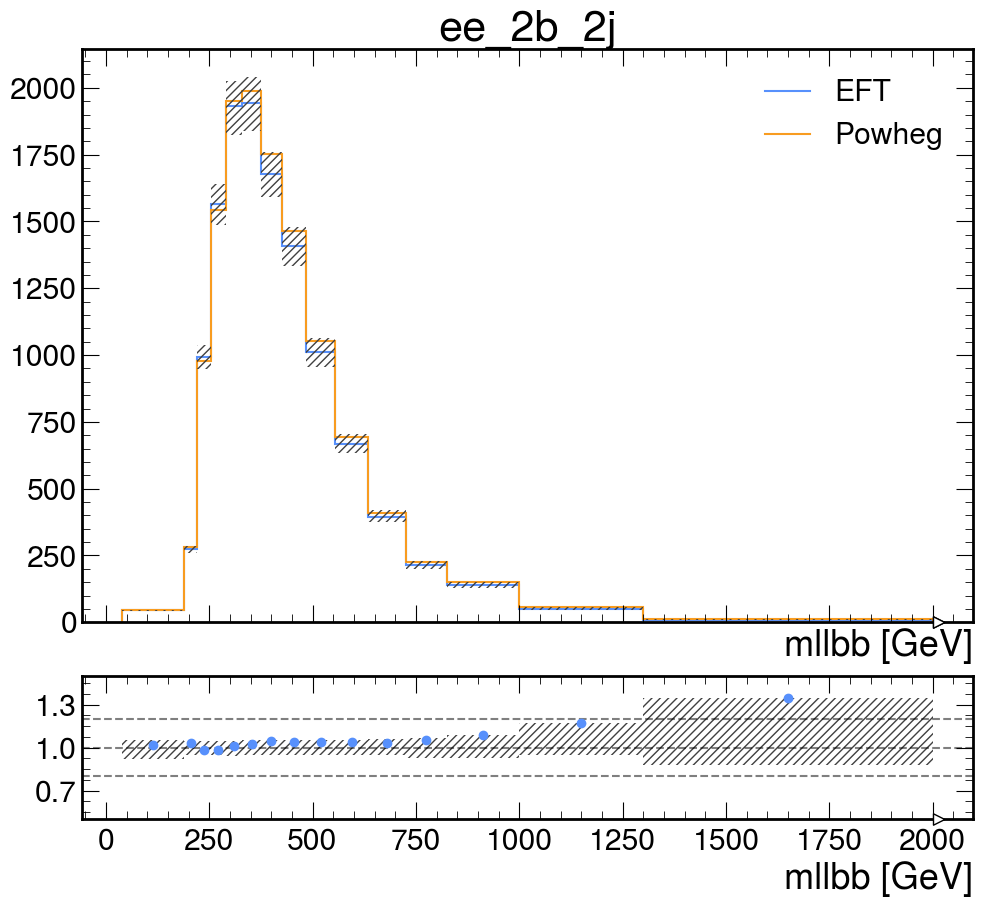

channel: ee_2b_3j


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


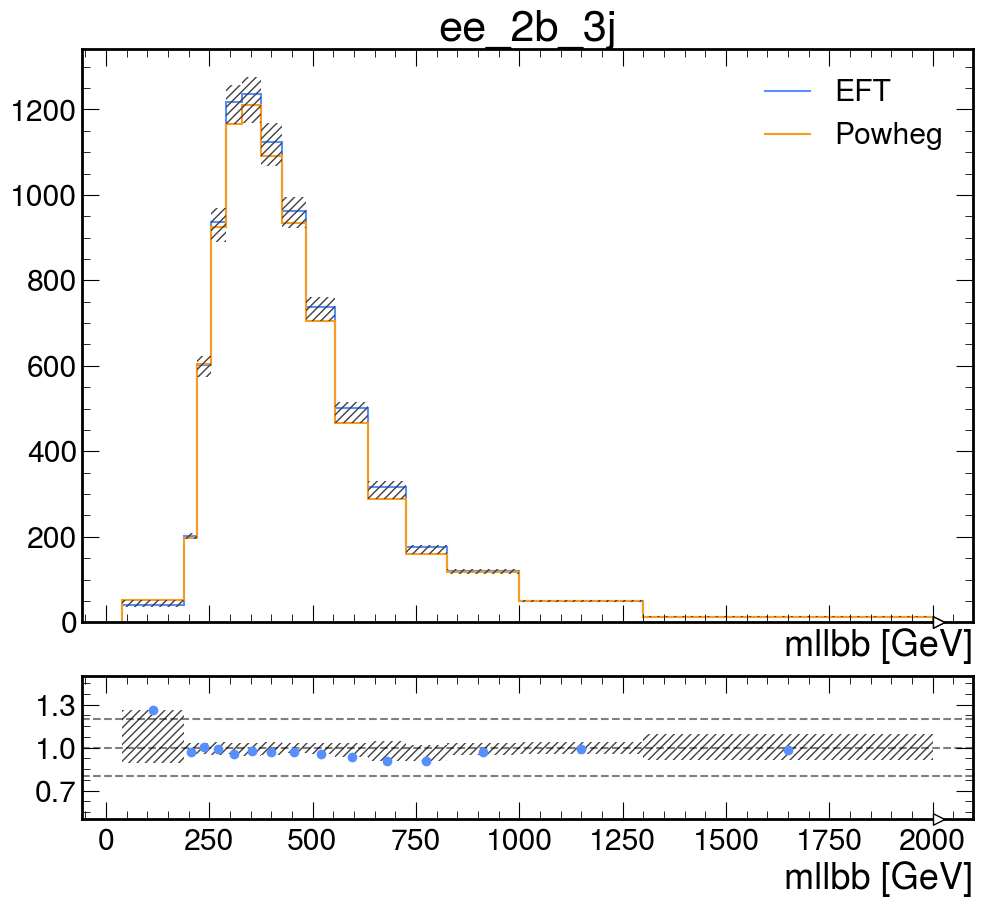

channel: ee_2b_4j


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


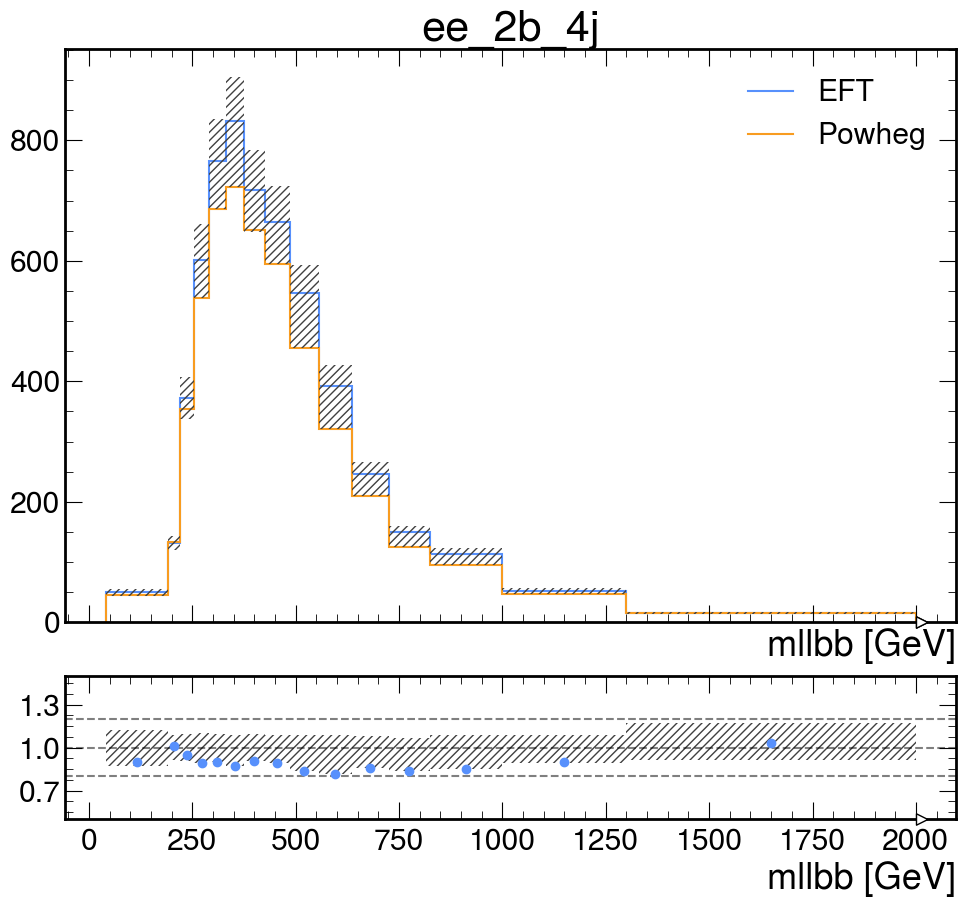

channel: mm_2b_2j


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


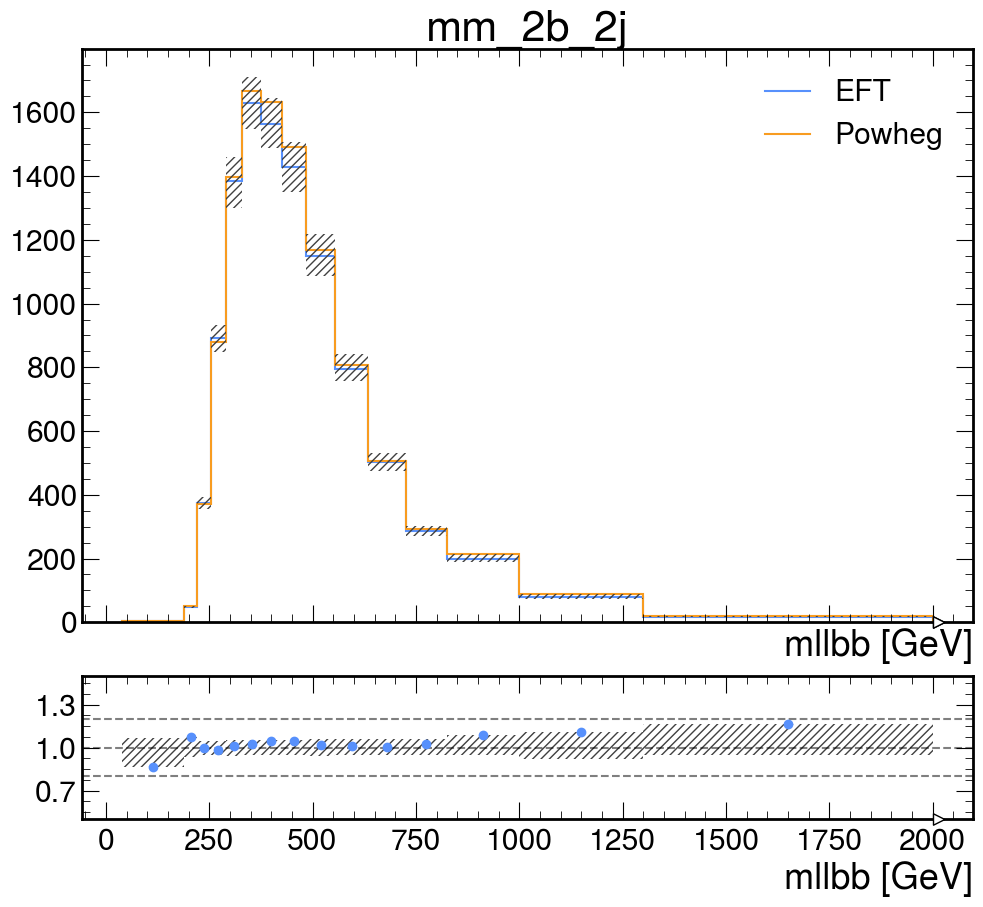

channel: mm_2b_3j


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


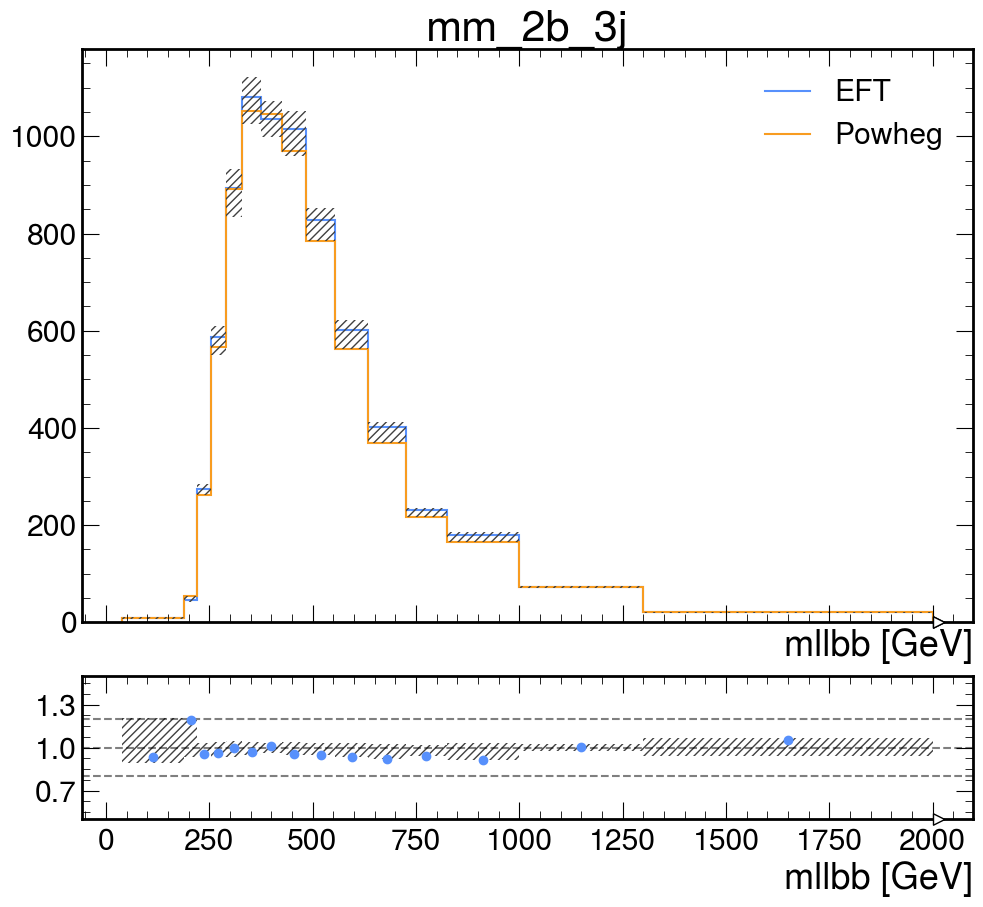

channel: mm_2b_4j


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


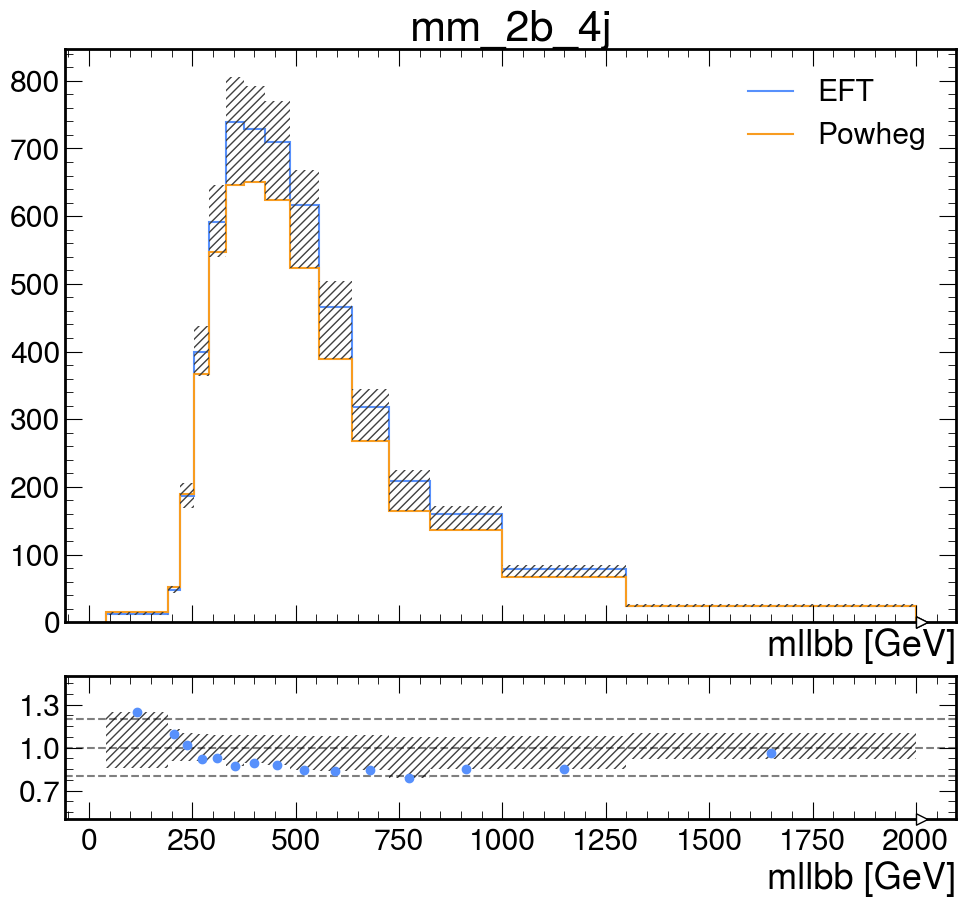

channel: em_2b_2j


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


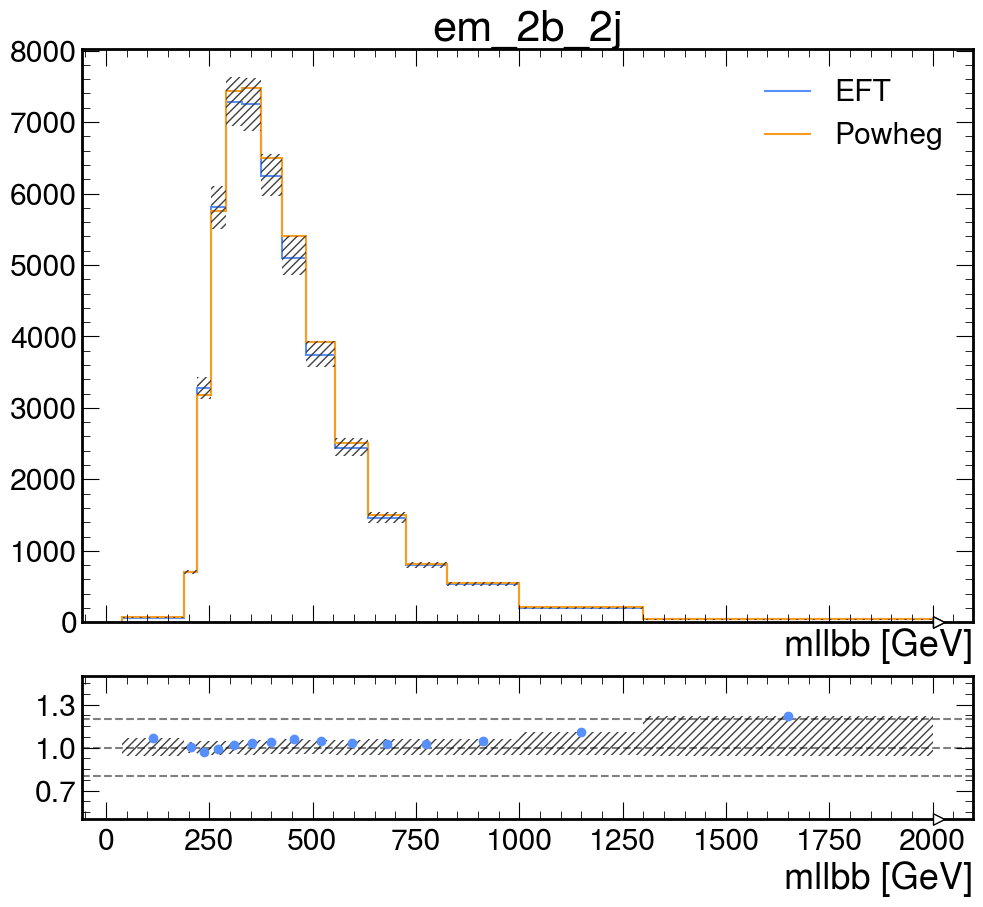

channel: em_2b_3j


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


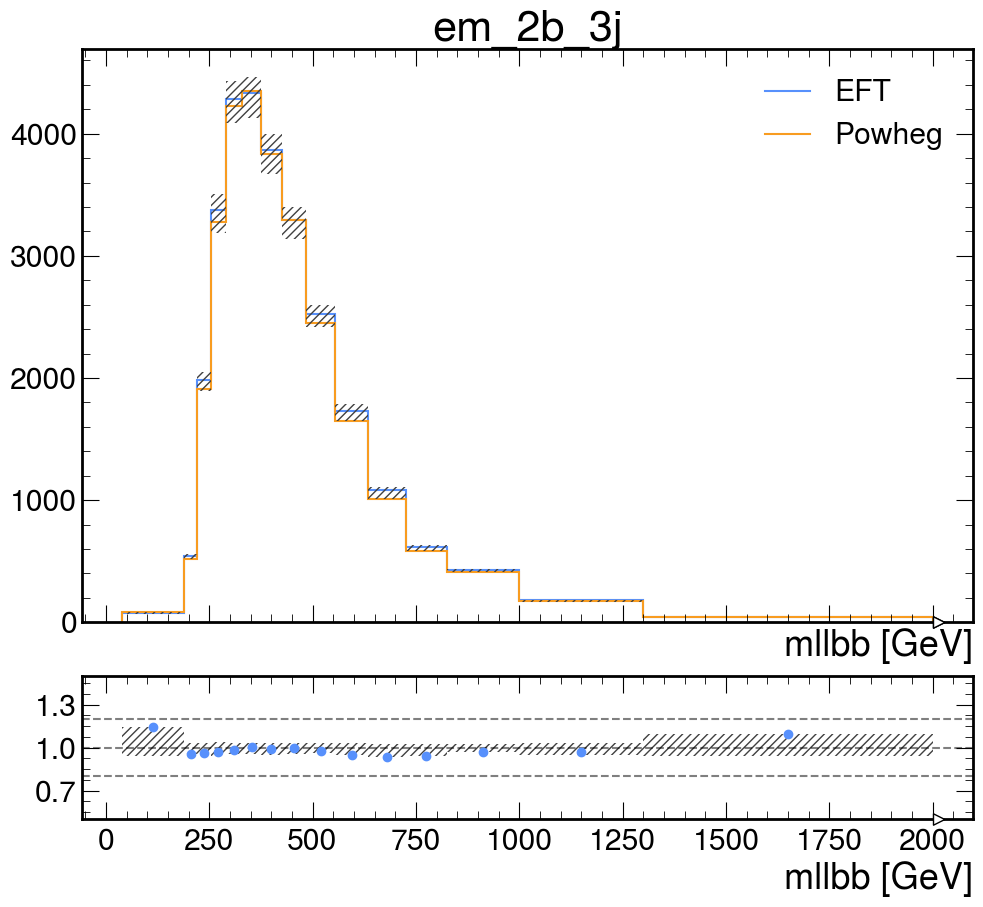

channel: em_2b_4j


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties


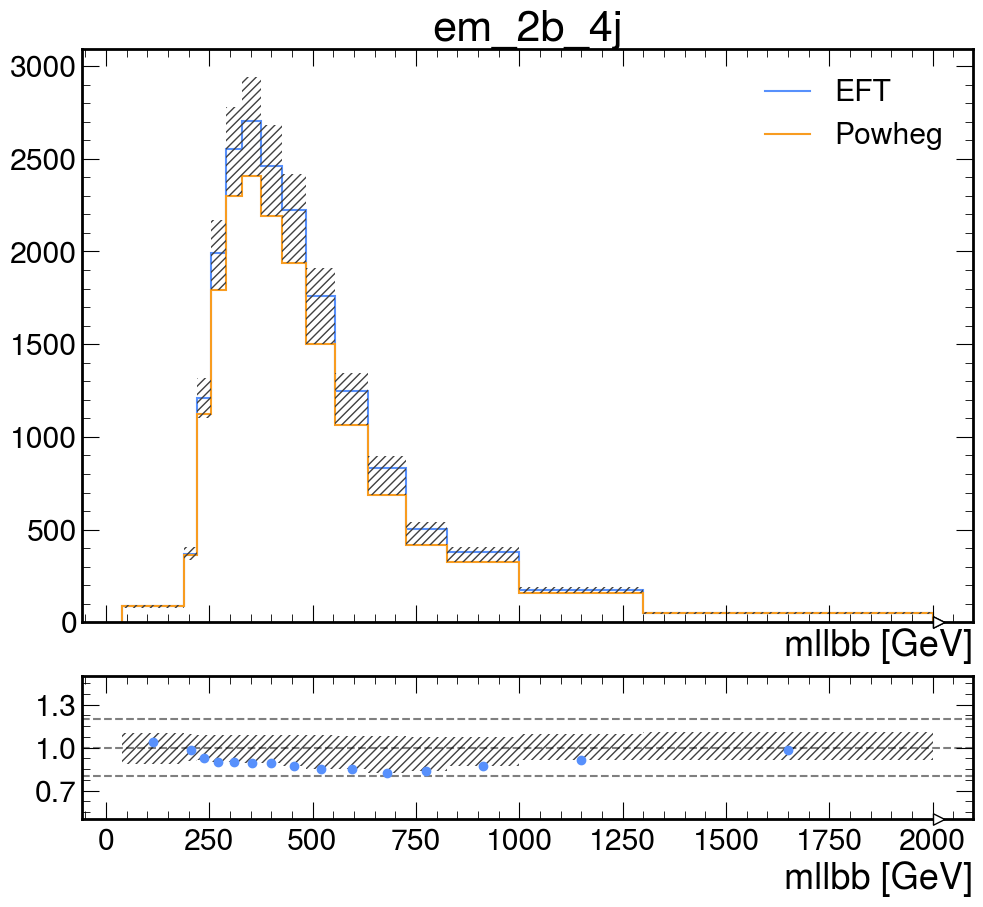

In [58]:
var = 'mllbb'
for d in hists_EFT.keys():
    h_EFTbase = hists_EFT[d][var]
    h_Powhegbase = hists_powheg[d][var]
    EFT_tt_procs = [x for x in list(h_EFTbase.axes['process']) if 'TT01j2l' in x]
    Powheg_tt_procs = [x for x in list(h_Powhegbase.axes['process']) if 'TTTo' in x]
    channels = list(h_EFTbase.axes['channel'])
    theory_systs = ['hdamp', 'FSR', 'ISR', 'renorm', 'fact', 'PDF']

    h_PDFweights_EFT = hists_EFT[d]['LHEPDFweights']# [{'channel':ch}]
    # h_PDFweights_POW = hists_powheg[d]['LHEPDFweights']# [{'channel':ch}]
    
    for ch in channels: 
        print(f"channel: {ch}")
        # POW_syst = h_Powhegbase[{'channel':ch, 'process':Powheg_tt_procs}].as_hist({})
        EFT_syst = h_EFTbase[{'channel':ch, 'process':EFT_tt_procs}].as_hist({})
        POW_nom = h_Powhegbase[{'systematic':'nominal', 'channel':ch, 'process':Powheg_tt_procs}][{'process':sum}].as_hist({})
        EFT_nom = h_EFTbase[{'systematic':'nominal', 'channel':ch, 'process':EFT_tt_procs}][{'process':sum}].as_hist({})
        
        h_PDFweights_EFT_ch = h_PDFweights_EFT[{'channel':ch}]
        # h_PDFweights_POW_ch = h_PDFweights_POW[{'channel':ch}]
        
        EFT_shape_systs_summed_arr_m , EFT_shape_systs_summed_arr_p = get_shape_syst_arrs(EFT_syst, syst_var_lst=theory_systs, PDF_var_histo=h_PDFweights_EFT_ch)
        
        nom_arr_all = EFT_nom.values()
        p_err_arr = nom_arr_all + np.sqrt(EFT_shape_systs_summed_arr_p)
        m_err_arr = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m)
        
        POW_arr_all = POW_nom.values()
        # snapped_powheg = np.clip(POW_arr_all, m_err_arr, p_err_arr)
        # missing_delta = np.abs(POW_arr_all - snapped_powheg)
        
        total_distance_squared = (POW_arr_all - nom_arr_all) ** 2
        powheg_is_above = (POW_arr_all >= nom_arr_all)
        missing_variance_p = np.where(
            powheg_is_above, 
            np.maximum(0.0, total_distance_squared - EFT_shape_systs_summed_arr_p), 
            0.0
        )
        missing_variance_m = np.where(
            ~powheg_is_above, 
            np.maximum(0.0, total_distance_squared - EFT_shape_systs_summed_arr_m), 
            0.0
        )
        
        p_err_arr = nom_arr_all + np.sqrt(EFT_shape_systs_summed_arr_p+missing_variance_p)
        m_err_arr = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m+missing_variance_m)
        
        fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(11.5,10),                                        # figsize=(10,12), # figsize=(11.5,10), figsize =(10, 10)
            gridspec_kw={'height_ratios': (4, 1), 'hspace':0.15},     # gridspec_kw={'height_ratios': (3, 1), 'hspace':0.05},
            sharex=True
        )

        hep.style.use("CMS")

        hep.histplot(
            EFT_nom,
            stack=True,
            histtype="step",
            yerr=False,
            label=f"EFT",
            ax=ax
        )
        
        hep.histplot(
            POW_nom,
            stack=True,
            histtype="step",
            yerr=False,
            label=f"Powheg",
            ax=ax
        )
        
        ratio = POW_nom/EFT_nom 
        hep.histplot(
            ratio, 
            histtype='errorbar',
            markersize=12,
            ax=rax
        )
        
        
        mc_vals = EFT_nom.values()
        bin_edges = np.asarray(EFT_nom.axes.edges[0])
        bin_centers = EFT_nom.axes.centers

        ### add syst uncertainty band to main plot ###
        p_err_arr = np.where(mc_vals>0,p_err_arr,0)
        m_err_arr = np.where(mc_vals>0,m_err_arr,0)

        ax.fill_between(
            bin_edges, 
            np.append(m_err_arr, m_err_arr[-1]),
            np.append(p_err_arr, p_err_arr[-1]),
            # step='post', 
            # hatch='\\\\\\\\\\',
            # alpha=0.5,
            step='post', 
            hatch='////',
            edgecolor= '#404040',# 'dimgray',  
            facecolor='none',
            linewidth=0,
        )

        ### add syst uncertainty band to ratio plot ###
        p_err_arr_ratio = np.where(mc_vals>0,p_err_arr/mc_vals,1)
        m_err_arr_ratio = np.where(mc_vals>0,m_err_arr/mc_vals,1)

        rax.fill_between(
            bin_edges, 
            np.append(m_err_arr_ratio, m_err_arr_ratio[-1]), 
            np.append(p_err_arr_ratio, p_err_arr_ratio[-1]), 
            # step='post', 
            # hatch='\\\\\\\\\\',
            # # color='dimgrey',
            # alpha=0.1, 
            step='post', 
            hatch='////', # hatch='\\\\\\\\\\',
            # alpha=0.1, 
            edgecolor= '#404040',# 'dimgray',  
            facecolor='none',
            linewidth=0,
        )

        rax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
        rax.axhline(y=0.8, color='black', linestyle='--', alpha=0.5)
        rax.axhline(y=1.2, color='black', linestyle='--', alpha=0.5)
        rax.set_ylim([0.5, 1.5])                    # rax.set_ylim([0.5, 1.5])
        rax.set_yticks([0.7, 1.0, 1.3])             # rax.set_yticks([0.8, 1.0, 1.2, 1.4]) 

        ax.legend()
        ax.set_title(f"{ch}")
        plt.show()

In [48]:
var = 'mllbb'
d = 'em'
ch = 'em_2b_4j'

# for d in hists_EFT.keys():
h_EFTbase = hists_EFT[d][var]
h_Powhegbase = hists_powheg[d][var]
EFT_tt_procs = [x for x in list(h_EFTbase.axes['process']) if 'TT01j2l' in x]
Powheg_tt_procs = [x for x in list(h_Powhegbase.axes['process']) if 'TTTo' in x]
channels = list(h_EFTbase.axes['channel'])
theory_systs = ['hdamp', 'FSR', 'ISR', 'renorm', 'fact', 'PDF']

h_PDFweights_EFT = hists_EFT[d]['LHEPDFweights']# [{'channel':ch}]
# h_PDFweights_POW = hists_powheg[d]['LHEPDFweights']# [{'channel':ch}]
    
    # for ch in channels: 
print(f"channel: {ch}")
# POW_syst = h_Powhegbase[{'channel':ch, 'process':Powheg_tt_procs}].as_hist({})
EFT_syst = h_EFTbase[{'channel':ch, 'process':EFT_tt_procs}].as_hist({})
POW_nom = h_Powhegbase[{'systematic':'nominal', 'channel':ch, 'process':Powheg_tt_procs}][{'process':sum}].as_hist({})
EFT_nom = h_EFTbase[{'systematic':'nominal', 'channel':ch, 'process':EFT_tt_procs}][{'process':sum}].as_hist({})

h_PDFweights_EFT_ch = h_PDFweights_EFT[{'channel':ch}]
# h_PDFweights_POW_ch = h_PDFweights_POW[{'channel':ch}]

EFT_shape_systs_summed_arr_m , EFT_shape_systs_summed_arr_p = get_shape_syst_arrs(EFT_syst, syst_var_lst=theory_systs, PDF_var_histo=h_PDFweights_EFT_ch)

nom_arr_all = EFT_nom.values()
p_err_arr = nom_arr_all + np.sqrt(EFT_shape_systs_summed_arr_p)
m_err_arr = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m)

POW_arr_all = POW_nom.values()

snapped_powheg = np.clip(POW_arr_all, m_err_arr, p_err_arr)
missing_delta = POW_arr_all - snapped_powheg
new_lower_bound = m_err_arr + missing_delta

print(f"upper: \t\t\t lower: \t\t POW: \t\t\t Missing Delta: \t\t\t New Lower: ")
for i in range(6): 
    print(f"{p_err_arr[i]} \t {m_err_arr[i]} \t {POW_arr_all[i]} \t {missing_delta[i]} \t {new_lower_bound[i]}")

channel: em_2b_4j
running PDF uncertainties
upper: 			 lower: 		 POW: 			 Missing Delta: 			 New Lower: 
95.65753829825067 	 76.7178485065931 	 90.2413089686154 	 0.0 	 76.7178485065931
404.1752944021437 	 333.9205090553477 	 360.9820022507438 	 0.0 	 333.9205090553477
1316.0836749911507 	 1103.26290449747 	 1121.019086003922 	 0.0 	 1103.26290449747
2169.129187956496 	 1809.9924539187048 	 1793.9819797272603 	 -16.010474191444473 	 1793.9819797272603
2778.617695582834 	 2321.3034399792955 	 2297.148250561071 	 -24.15518941822438 	 2297.148250561071
2943.7560973880863 	 2460.446967287836 	 2405.8378297323334 	 -54.60913755550246 	 2405.8378297323334


channel: em_2b_4j


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
/tmp/ipykernel_1071512/3677676075.py:38: RuntimeWarning: invalid value encountered in sqrt
  new_uncert = np.sqrt(np.square(new_lower_bound - nom_arr_all)-EFT_shape_systs_summed_arr_m)


running PDF uncertainties
[  95.6575383   404.1752944  1316.08367499 2169.12918796 2778.61769558
 2943.75609739 2680.99149778 2417.71767769 1911.9241291  1346.57840677
  898.87200958  539.38793527  405.26942325  190.06265743   55.99626571]
[  76.71784851  333.92050906           nan 1793.98197973 2297.14825056
 2405.83782973 2192.1642141  1938.15638192 1503.43110626 1064.95245365
  688.36366162  417.33698017  327.27112996  159.30945475           nan]


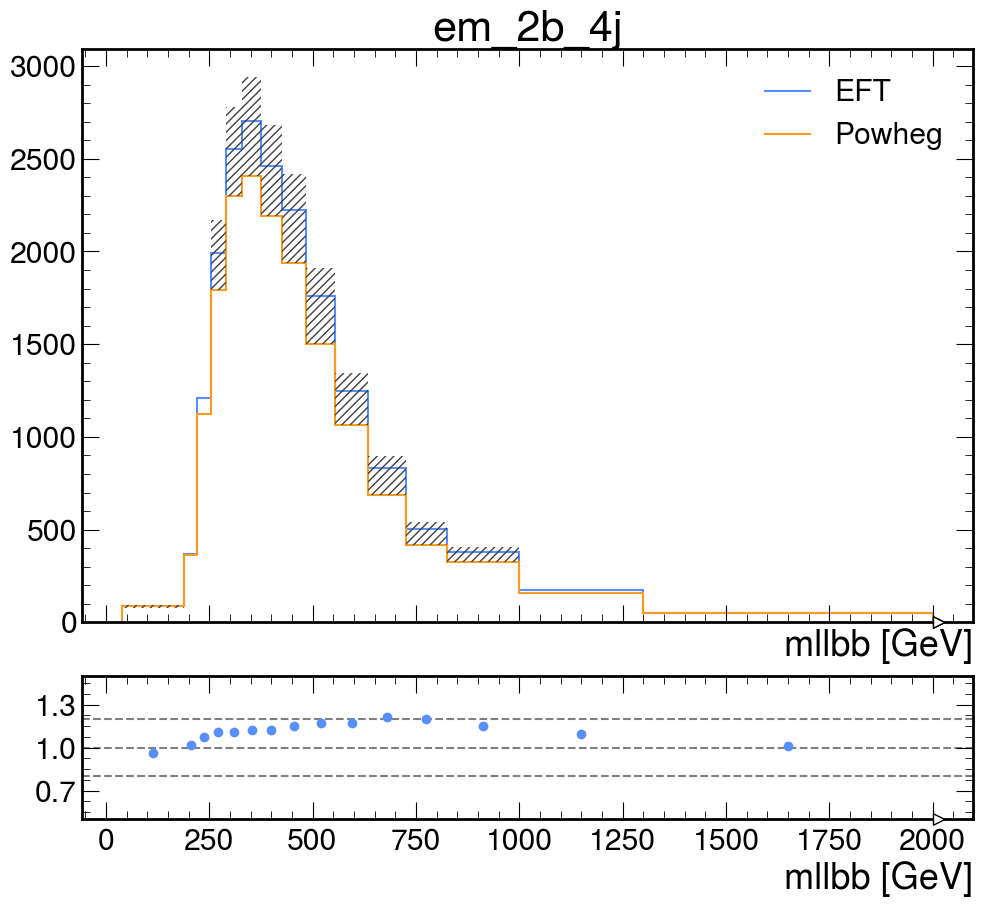

In [52]:
var = 'mllbb'
d = 'em'
ch = 'em_2b_4j'

# for d in hists_EFT.keys():
h_EFTbase = hists_EFT[d][var]
h_Powhegbase = hists_powheg[d][var]
EFT_tt_procs = [x for x in list(h_EFTbase.axes['process']) if 'TT01j2l' in x]
Powheg_tt_procs = [x for x in list(h_Powhegbase.axes['process']) if 'TTTo' in x]
channels = list(h_EFTbase.axes['channel'])
theory_systs = ['hdamp', 'FSR', 'ISR', 'renorm', 'fact', 'PDF']

h_PDFweights_EFT = hists_EFT[d]['LHEPDFweights']# [{'channel':ch}]
# h_PDFweights_POW = hists_powheg[d]['LHEPDFweights']# [{'channel':ch}]
    
    # for ch in channels: 
print(f"channel: {ch}")
# POW_syst = h_Powhegbase[{'channel':ch, 'process':Powheg_tt_procs}].as_hist({})
EFT_syst = h_EFTbase[{'channel':ch, 'process':EFT_tt_procs}].as_hist({})
POW_nom = h_Powhegbase[{'systematic':'nominal', 'channel':ch, 'process':Powheg_tt_procs}][{'process':sum}].as_hist({})
EFT_nom = h_EFTbase[{'systematic':'nominal', 'channel':ch, 'process':EFT_tt_procs}][{'process':sum}].as_hist({})

h_PDFweights_EFT_ch = h_PDFweights_EFT[{'channel':ch}]
# h_PDFweights_POW_ch = h_PDFweights_POW[{'channel':ch}]

EFT_shape_systs_summed_arr_m , EFT_shape_systs_summed_arr_p = get_shape_syst_arrs(EFT_syst, syst_var_lst=theory_systs, PDF_var_histo=h_PDFweights_EFT_ch)

nom_arr_all = EFT_nom.values()
p_err_arr = nom_arr_all + np.sqrt(EFT_shape_systs_summed_arr_p)
m_err_arr = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m)

POW_arr_all = POW_nom.values()

snapped_powheg = np.clip(POW_arr_all, m_err_arr, p_err_arr)
missing_delta = POW_arr_all - snapped_powheg
new_lower_bound = m_err_arr + missing_delta

new_uncert = np.sqrt(np.square(new_lower_bound - nom_arr_all)-EFT_shape_systs_summed_arr_m)
new_lower_bound = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m+np.square(new_uncert))
m_err_arr = new_lower_bound

fig, (ax, rax) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11.5,10),                                        # figsize=(10,12), # figsize=(11.5,10), figsize =(10, 10)
    gridspec_kw={'height_ratios': (4, 1), 'hspace':0.15},     # gridspec_kw={'height_ratios': (3, 1), 'hspace':0.05},
    sharex=True
)

hep.style.use("CMS")

hep.histplot(
    EFT_nom,
    stack=True,
    histtype="step",
    yerr=False,
    label=f"EFT",
    ax=ax
)

hep.histplot(
    POW_nom,
    stack=True,
    histtype="step",
    yerr=False,
    label=f"Powheg",
    ax=ax
)

ratio = EFT_nom/POW_nom 
hep.histplot(
    ratio, 
    histtype='errorbar',
    markersize=12,
    ax=rax
)


mc_vals = EFT_nom.values()
bin_edges = np.asarray(EFT_nom.axes.edges[0])
bin_centers = EFT_nom.axes.centers

### add syst uncertainty band to main plot ###
p_err_arr = np.where(mc_vals>0,p_err_arr,0)
m_err_arr = np.where(mc_vals>0,m_err_arr,0)

print(p_err_arr)
print(m_err_arr)

ax.fill_between(
    bin_edges, 
    np.append(m_err_arr, m_err_arr[-1]),
    np.append(p_err_arr, p_err_arr[-1]),
    # step='post', 
    # hatch='\\\\\\\\\\',
    # alpha=0.5,
    step='post', 
    hatch='////',
    edgecolor= '#404040',# 'dimgray',  
    facecolor='none',
    linewidth=0,
)

# ### add syst uncertainty band to ratio plot ###
# p_err_arr_ratio = np.where(mc_vals>0,p_err_arr/mc_vals,1)
# m_err_arr_ratio = np.where(mc_vals>0,m_err_arr/mc_vals,1)

# rax.fill_between(
#     bin_edges, 
#     np.append(m_err_arr_ratio, m_err_arr_ratio[-1]), 
#     np.append(p_err_arr_ratio, p_err_arr_ratio[-1]), 
#     # step='post', 
#     # hatch='\\\\\\\\\\',
#     # # color='dimgrey',
#     # alpha=0.1, 
#     step='post', 
#     hatch='////', # hatch='\\\\\\\\\\',
#     # alpha=0.1, 
#     edgecolor= '#404040',# 'dimgray',  
#     facecolor='none',
#     linewidth=0,
# )

rax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
rax.axhline(y=0.8, color='black', linestyle='--', alpha=0.5)
rax.axhline(y=1.2, color='black', linestyle='--', alpha=0.5)
rax.set_ylim([0.5, 1.5])                    # rax.set_ylim([0.5, 1.5])
rax.set_yticks([0.7, 1.0, 1.3])             # rax.set_yticks([0.8, 1.0, 1.2, 1.4]) 

ax.legend()
ax.set_title(f"{ch}")
plt.show()

channel: em_2b_4j


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties
[  95.6575383   404.1752944  1316.08367499 2169.12918796 2778.61769558
 2943.75609739 2680.99149778 2417.71767769 1911.9241291  1346.57840677
  898.87200958  539.38793527  405.26942325  190.06265743   55.99626571]
[  76.71784851  333.92050906 1103.2629045  1793.98197973 2297.14825056
 2405.83782973 2192.1642141  1938.15638192 1503.43110626 1064.95245365
  688.36366162  417.33698017  327.27112996  159.30945475   46.13546885]


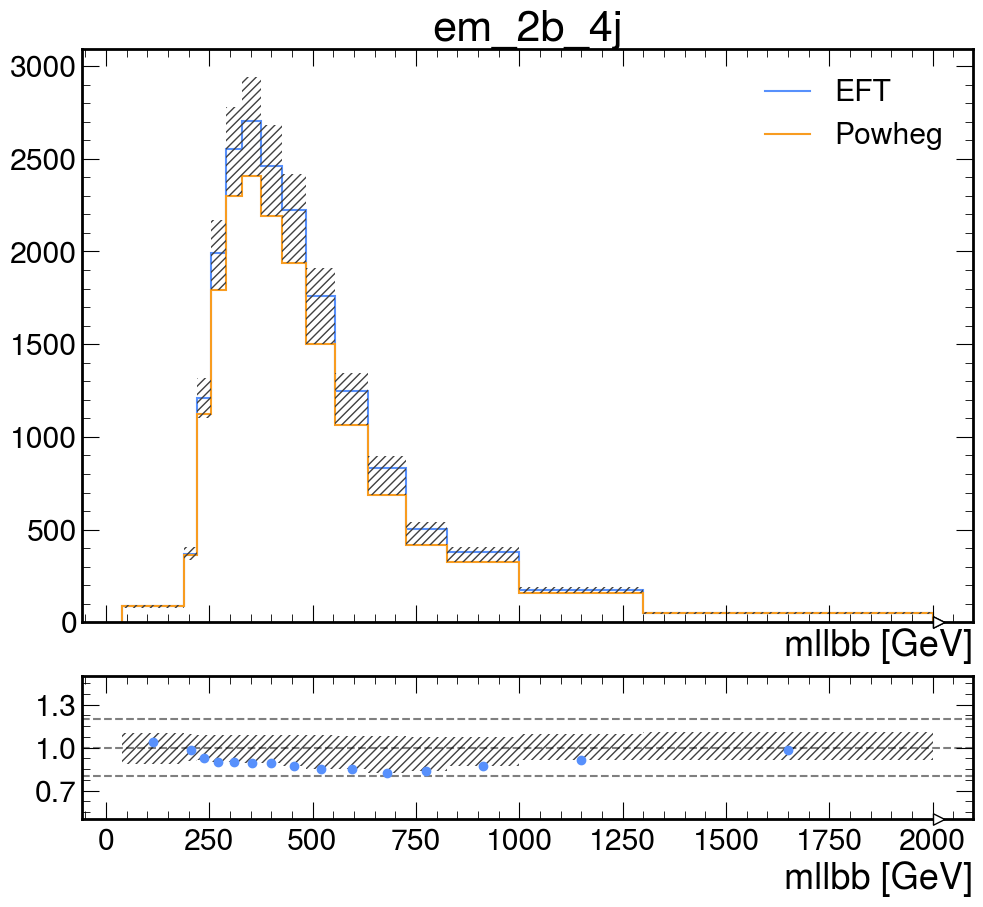

In [57]:
var = 'mllbb'
d = 'em'
ch = 'em_2b_4j'

# for d in hists_EFT.keys():
h_EFTbase = hists_EFT[d][var]
h_Powhegbase = hists_powheg[d][var]
EFT_tt_procs = [x for x in list(h_EFTbase.axes['process']) if 'TT01j2l' in x]
Powheg_tt_procs = [x for x in list(h_Powhegbase.axes['process']) if 'TTTo' in x]
channels = list(h_EFTbase.axes['channel'])
theory_systs = ['hdamp', 'FSR', 'ISR', 'renorm', 'fact', 'PDF']

h_PDFweights_EFT = hists_EFT[d]['LHEPDFweights']# [{'channel':ch}]
# h_PDFweights_POW = hists_powheg[d]['LHEPDFweights']# [{'channel':ch}]
    
    # for ch in channels: 
print(f"channel: {ch}")
# POW_syst = h_Powhegbase[{'channel':ch, 'process':Powheg_tt_procs}].as_hist({})
EFT_syst = h_EFTbase[{'channel':ch, 'process':EFT_tt_procs}].as_hist({})
POW_nom = h_Powhegbase[{'systematic':'nominal', 'channel':ch, 'process':Powheg_tt_procs}][{'process':sum}].as_hist({})
EFT_nom = h_EFTbase[{'systematic':'nominal', 'channel':ch, 'process':EFT_tt_procs}][{'process':sum}].as_hist({})

h_PDFweights_EFT_ch = h_PDFweights_EFT[{'channel':ch}]

EFT_shape_systs_summed_arr_m , EFT_shape_systs_summed_arr_p = get_shape_syst_arrs(EFT_syst, syst_var_lst=theory_systs, PDF_var_histo=h_PDFweights_EFT_ch)
nom_arr_all = EFT_nom.values()
p_err_arr = nom_arr_all + np.sqrt(EFT_shape_systs_summed_arr_p)
m_err_arr = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m)
POW_arr_all = POW_nom.values()

missing_delta_m = np.minimum(0.0, POW_arr_all - m_err_arr)
new_lower_bound = m_err_arr + missing_delta_m
new_uncert_m_sq = np.maximum(0.0, np.square(new_lower_bound - nom_arr_all) - EFT_shape_systs_summed_arr_m)
m_err_arr = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m + new_uncert_m_sq)

missing_delta_p = np.maximum(0.0, POW_arr_all - p_err_arr)
new_upper_bound = p_err_arr + missing_delta_p
new_uncert_p_sq = np.maximum(0.0, np.square(new_upper_bound - nom_arr_all) - EFT_shape_systs_summed_arr_p)
p_err_arr = nom_arr_all + np.sqrt(EFT_shape_systs_summed_arr_p + new_uncert_p_sq)

fig, (ax, rax) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11.5,10),                                        # figsize=(10,12), # figsize=(11.5,10), figsize =(10, 10)
    gridspec_kw={'height_ratios': (4, 1), 'hspace':0.15},     # gridspec_kw={'height_ratios': (3, 1), 'hspace':0.05},
    sharex=True
)

hep.style.use("CMS")

hep.histplot(
    EFT_nom,
    stack=True,
    histtype="step",
    yerr=False,
    label=f"EFT",
    ax=ax
)

hep.histplot(
    POW_nom,
    stack=True,
    histtype="step",
    yerr=False,
    label=f"Powheg",
    ax=ax
)

# ratio = EFT_nom/POW_nom 
ratio = POW_nom/EFT_nom
hep.histplot(
    ratio, 
    histtype='errorbar',
    markersize=12,
    ax=rax
)


mc_vals = EFT_nom.values()
bin_edges = np.asarray(EFT_nom.axes.edges[0])
bin_centers = EFT_nom.axes.centers

### add syst uncertainty band to main plot ###
p_err_arr = np.where(mc_vals>0,p_err_arr,0)
m_err_arr = np.where(mc_vals>0,m_err_arr,0)

print(p_err_arr)
print(m_err_arr)

ax.fill_between(
    bin_edges, 
    np.append(m_err_arr, m_err_arr[-1]),
    np.append(p_err_arr, p_err_arr[-1]),
    # step='post', 
    # hatch='\\\\\\\\\\',
    # alpha=0.5,
    step='post', 
    hatch='////',
    edgecolor= '#404040',# 'dimgray',  
    facecolor='none',
    linewidth=0,
)

### add syst uncertainty band to ratio plot ###
p_err_arr_ratio = np.where(mc_vals>0,p_err_arr/mc_vals,1)
m_err_arr_ratio = np.where(mc_vals>0,m_err_arr/mc_vals,1)

rax.fill_between(
    bin_edges, 
    np.append(m_err_arr_ratio, m_err_arr_ratio[-1]), 
    np.append(p_err_arr_ratio, p_err_arr_ratio[-1]), 
    # step='post', 
    # hatch='\\\\\\\\\\',
    # # color='dimgrey',
    # alpha=0.1, 
    step='post', 
    hatch='////', # hatch='\\\\\\\\\\',
    # alpha=0.1, 
    edgecolor= '#404040',# 'dimgray',  
    facecolor='none',
    linewidth=0,
)

rax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
rax.axhline(y=0.8, color='black', linestyle='--', alpha=0.5)
rax.axhline(y=1.2, color='black', linestyle='--', alpha=0.5)
rax.set_ylim([0.5, 1.5])                    # rax.set_ylim([0.5, 1.5])
rax.set_yticks([0.7, 1.0, 1.3])             # rax.set_yticks([0.8, 1.0, 1.2, 1.4]) 

ax.legend()
ax.set_title(f"{ch}")
plt.show()

channel: em_2b_4j


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


running PDF uncertainties
[  95.6575383   404.1752944  1316.08367499 2169.12918796 2778.61769558
 2943.75609739 2680.99149778 2417.71767769 1911.9241291  1346.57840677
  898.87200958  539.38793527  405.26942325  190.06265743   55.99626571]
[  76.71784851  333.92050906 1103.2629045  1809.99245392 2321.30343998
 2460.44696729 2247.2925927  2034.43532808 1621.96574281 1154.90877655
  769.10518227  464.98642794  348.01884287  160.71057647   46.13546885]


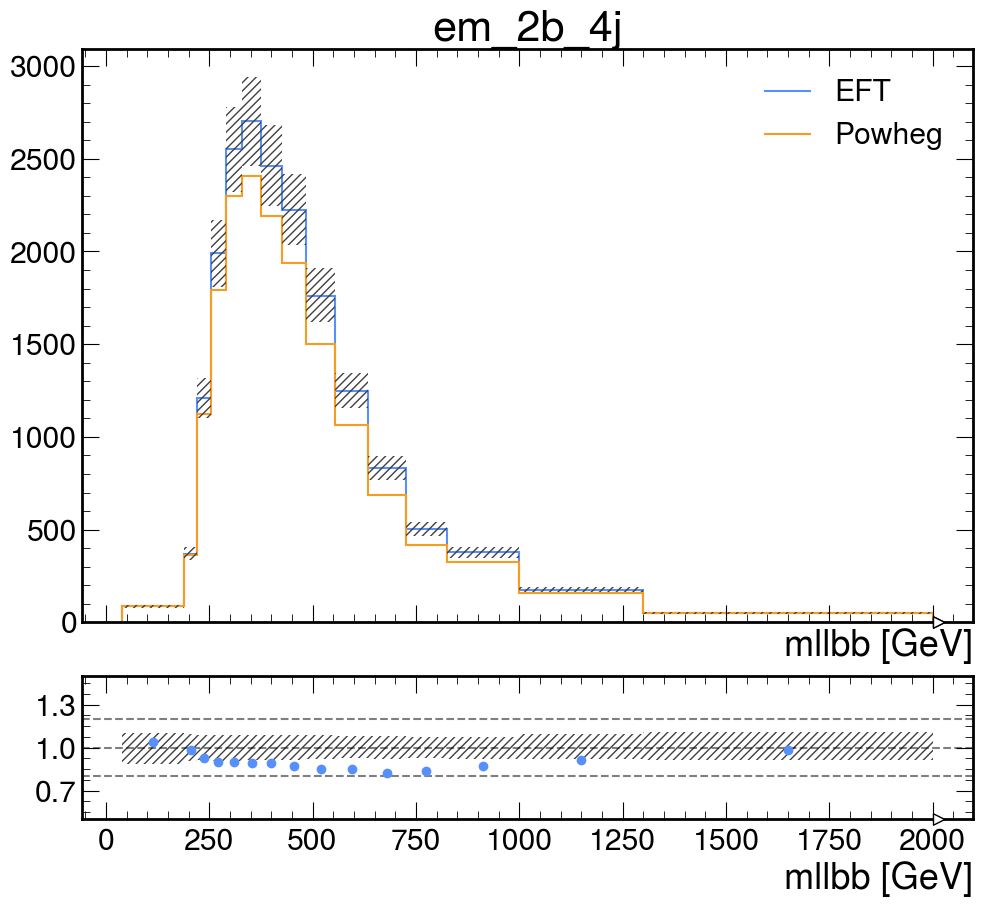

In [59]:
var = 'mllbb'
d = 'em'
ch = 'em_2b_4j'

# for d in hists_EFT.keys():
h_EFTbase = hists_EFT[d][var]
h_Powhegbase = hists_powheg[d][var]
EFT_tt_procs = [x for x in list(h_EFTbase.axes['process']) if 'TT01j2l' in x]
Powheg_tt_procs = [x for x in list(h_Powhegbase.axes['process']) if 'TTTo' in x]
channels = list(h_EFTbase.axes['channel'])
theory_systs = ['hdamp', 'FSR', 'ISR', 'renorm', 'fact', 'PDF']

h_PDFweights_EFT = hists_EFT[d]['LHEPDFweights']# [{'channel':ch}]
# h_PDFweights_POW = hists_powheg[d]['LHEPDFweights']# [{'channel':ch}]
    
    # for ch in channels: 
print(f"channel: {ch}")
# POW_syst = h_Powhegbase[{'channel':ch, 'process':Powheg_tt_procs}].as_hist({})
EFT_syst = h_EFTbase[{'channel':ch, 'process':EFT_tt_procs}].as_hist({})
POW_nom = h_Powhegbase[{'systematic':'nominal', 'channel':ch, 'process':Powheg_tt_procs}][{'process':sum}].as_hist({})
EFT_nom = h_EFTbase[{'systematic':'nominal', 'channel':ch, 'process':EFT_tt_procs}][{'process':sum}].as_hist({})

h_PDFweights_EFT_ch = h_PDFweights_EFT[{'channel':ch}]

EFT_shape_systs_summed_arr_m , EFT_shape_systs_summed_arr_p = get_shape_syst_arrs(EFT_syst, syst_var_lst=theory_systs, PDF_var_histo=h_PDFweights_EFT_ch)
nom_arr_all = EFT_nom.values()
p_err_arr = nom_arr_all + np.sqrt(EFT_shape_systs_summed_arr_p)
m_err_arr = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m)
# POW_arr_all = POW_nom.values()

# missing_delta_m = np.minimum(0.0, POW_arr_all - m_err_arr)
# new_lower_bound = m_err_arr + missing_delta_m
# new_uncert_m_sq = np.maximum(0.0, np.square(new_lower_bound - nom_arr_all) - EFT_shape_systs_summed_arr_m)
# m_err_arr = nom_arr_all - np.sqrt(EFT_shape_systs_summed_arr_m + new_uncert_m_sq)

# missing_delta_p = np.maximum(0.0, POW_arr_all - p_err_arr)
# new_upper_bound = p_err_arr + missing_delta_p
# new_uncert_p_sq = np.maximum(0.0, np.square(new_upper_bound - nom_arr_all) - EFT_shape_systs_summed_arr_p)
# p_err_arr = nom_arr_all + np.sqrt(EFT_shape_systs_summed_arr_p + new_uncert_p_sq)

fig, (ax, rax) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11.5,10),                                        # figsize=(10,12), # figsize=(11.5,10), figsize =(10, 10)
    gridspec_kw={'height_ratios': (4, 1), 'hspace':0.15},     # gridspec_kw={'height_ratios': (3, 1), 'hspace':0.05},
    sharex=True
)

hep.style.use("CMS")

hep.histplot(
    EFT_nom,
    stack=True,
    histtype="step",
    yerr=False,
    label=f"EFT",
    ax=ax
)

hep.histplot(
    POW_nom,
    stack=True,
    histtype="step",
    yerr=False,
    label=f"Powheg",
    ax=ax
)

# ratio = EFT_nom/POW_nom 
ratio = POW_nom/EFT_nom
hep.histplot(
    ratio, 
    histtype='errorbar',
    markersize=12,
    ax=rax
)


mc_vals = EFT_nom.values()
bin_edges = np.asarray(EFT_nom.axes.edges[0])
bin_centers = EFT_nom.axes.centers

### add syst uncertainty band to main plot ###
p_err_arr = np.where(mc_vals>0,p_err_arr,0)
m_err_arr = np.where(mc_vals>0,m_err_arr,0)

print(p_err_arr)
print(m_err_arr)

ax.fill_between(
    bin_edges, 
    np.append(m_err_arr, m_err_arr[-1]),
    np.append(p_err_arr, p_err_arr[-1]),
    # step='post', 
    # hatch='\\\\\\\\\\',
    # alpha=0.5,
    step='post', 
    hatch='////',
    edgecolor= '#404040',# 'dimgray',  
    facecolor='none',
    linewidth=0,
)

### add syst uncertainty band to ratio plot ###
p_err_arr_ratio = np.where(mc_vals>0,p_err_arr/mc_vals,1)
m_err_arr_ratio = np.where(mc_vals>0,m_err_arr/mc_vals,1)

rax.fill_between(
    bin_edges, 
    np.append(m_err_arr_ratio, m_err_arr_ratio[-1]), 
    np.append(p_err_arr_ratio, p_err_arr_ratio[-1]), 
    # step='post', 
    # hatch='\\\\\\\\\\',
    # # color='dimgrey',
    # alpha=0.1, 
    step='post', 
    hatch='////', # hatch='\\\\\\\\\\',
    # alpha=0.1, 
    edgecolor= '#404040',# 'dimgray',  
    facecolor='none',
    linewidth=0,
)

rax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
rax.axhline(y=0.8, color='black', linestyle='--', alpha=0.5)
rax.axhline(y=1.2, color='black', linestyle='--', alpha=0.5)
rax.set_ylim([0.5, 1.5])                    # rax.set_ylim([0.5, 1.5])
rax.set_yticks([0.7, 1.0, 1.3])             # rax.set_yticks([0.8, 1.0, 1.2, 1.4]) 

ax.legend()
ax.set_title(f"{ch}")
plt.show()